# Text Analytics Coursework

This notebook provides some example code for loading and examining the dataset for task 3. 

In [1]:
# Optional: if other Hugging Face loads still hit `**` glob errors, run this cell to upgrade packages,
# then Kernel → Restart Kernel and Run All. arXiv loading now uses an explicit jsonl path—you usually do not need this cell.
import subprocess
import sys

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-U",
        "datasets>=2.19.0",
        "huggingface_hub>=0.21.2",
        "fsspec",
    ]
)
print("Done. Restart the kernel, then Run All.")


  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
Done. Restart the kernel, then Run All.


In [2]:
%load_ext autoreload
%autoreload 2

# Avoid silent kernel crashes from UMAP/BLAS multi-threading vs Jupyter on macOS (set before importing numpy).
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd


# Task 3 - arXiv abstracts

This dataset contains arXiv abstracts over a many year. Let's first load it and examine the fields:

In [3]:
from datasets import Dataset, concatenate_datasets
import os, glob

_ARROW_DIR = os.path.join(
    "/Users/bryanlu/Desktop/Introduction to AI and Text Analytics",
    ".hf_datasets_cache",
    "json/default-f267224cc2fd5d67/0.0.0",
    "8bb11242116d547c741b2e8a1f18598ffdd40a1d4f2a2872c7a28b697434bc96",
)

arrow_files = sorted(glob.glob(os.path.join(_ARROW_DIR, "json-train-*.arrow")))
dataset = concatenate_datasets([Dataset.from_file(f) for f in arrow_files])

print(f"Loaded {len(dataset)} rows from local cache")
print(dataset[0])


Loaded 1999486 rows from local cache
{'id': '0704.0001', 'submitter': 'Pavel Nadolsky', 'authors': "C. Bal\\'azs, E. L. Berger, P. M. Nadolsky, C.-P. Yuan", 'title': 'Calculation of prompt diphoton production cross sections at Tevatron and\n  LHC energies', 'comments': '37 pages, 15 figures; published version', 'journal-ref': 'Phys.Rev.D76:013009,2007', 'doi': '10.1103/PhysRevD.76.013009', 'abstract': '  A fully differential calculation in perturbative quantum chromodynamics is\npresented for the production of massive photon pairs at hadron colliders. All\nnext-to-leading order perturbative contributions from quark-antiquark,\ngluon-(anti)quark, and gluon-gluon subprocesses are included, as well as\nall-orders resummation of initial-state gluon radiation valid at\nnext-to-next-to-leading logarithmic accuracy. The region of phase space is\nspecified in which the calculation is most reliable. Good agreement is\ndemonstrated with data from the Fermilab Tevatron, and predictions are made f

We can now filter it to get abstracts about a particular topic or field:

In [4]:

# filter by category
field = "cs.LG"  # Focus on Machine Learning
def filter_category(example):
    return field in example['categories']

filtered = dataset.filter(filter_category)

# Remove missing/short abstracts
def valid_abstract(example):
    return example['abstract'] is not None and len(example['abstract']) > 50

filtered = filtered.filter(valid_abstract)

Another useful step is to get the date of each abstract, e.g., for plotting trends. This is not stored in the dataset object, but we can infer it from the ID. 

In [5]:
# -----------------------
# Infer year from arXiv ID
# -----------------------
def extract_year(arxiv_id):
    if arxiv_id.startswith("cs/"):
        arxiv_id = arxiv_id.split("/")[1]
    yy = int(arxiv_id[:2])
    return 1900 + yy if yy >= 91 else 2000 + yy

years = [extract_year(x) for x in filtered["id"]]

# -----------------------
# Prepare docs
# -----------------------
docs = filtered['abstract']

In [6]:
import pandas as pd

df = pd.DataFrame({
    "id": filtered["id"],
    "categories": filtered["categories"],
    "year": years,
    "field": [field] * len(filtered),#all the same
    "abstract": filtered["abstract"]
})

pd.set_option('display.max_colwidth', None)  # no column width limit
pd.set_option('display.max_rows', None)     # no row limit
print(df["abstract"].head(1))
print(df.shape)


0      This paper uncovers and explores the close relationship between Monte Carlo\nOptimization of a parametrized integral (MCO), Parametric machine-Learning\n(PL), and `blackbox' or `oracle'-based optimization (BO). We make four\ncontributions. First, we prove that MCO is mathematically identical to a broad\nclass of PL problems. This identity potentially provides a new application\ndomain for all broadly applicable PL techniques: MCO. Second, we introduce\nimmediate sampling, a new version of the Probability Collectives (PC) algorithm\nfor blackbox optimization. Immediate sampling transforms the original BO\nproblem into an MCO problem. Accordingly, by combining these first two\ncontributions, we can apply all PL techniques to BO. In our third contribution\nwe validate this way of improving BO by demonstrating that cross-validation and\nbagging improve immediate sampling. Finally, conventional MC and MCO procedures\nignore the relationship between the sample point locations and the 

In [7]:
# This code performs text preprocessing to prepare the corpus for later analysis in Task 3.
# It defines two different preprocessing pipelines:
# 1. preprocess_for_tfidf_lda(): stronger preprocessing for TF-IDF and LDA
#    - lowercase conversion
#    - newline removal
#    - removal of non-letter characters
#    - tokenization
#    - stopword removal
#    - lemmatization
#    - removal of very short words
#
# 2. preprocess_for_embedding(): lighter preprocessing for embedding-based methods
#    - preserves the original sentence structure
#    - only removes extra newlines and spaces
#
# In Task 3, this step is important because it:
# - creates clean token-based input for TF-IDF and LDA
# - preserves richer semantic information for embedding-based models such as BERTopic
# - ensures that each method receives the most suitable text representation for fair comparison


import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# need to download for the first time 
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


# 1) preprocessing for TF-IDF / LDA 
# Preprocessing for TF-IDF / LDA


def preprocess_for_tfidf_lda(text, stop_words_set=None):
    if pd.isna(text):
        return []

    if stop_words_set is None:
        stop_words_set = set()

    text = text.lower()
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-z\s]", " ", text)

    tokens = word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words_set and len(token) > 2
    ]

    return tokens


# 2)  preprocessing for embedding
# Lighter preprocessing for embeddings
# -----------------------
def preprocess_for_embedding(text):
    if pd.isna(text):
        return ""
    
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text
# apply to df

df["tokens"] = df["abstract"].apply(preprocess_for_tfidf_lda)
df["clean_text_tfidf_lda"] = df["tokens"].apply(lambda x: " ".join(x))
df["clean_text_embed"] = df["abstract"].apply(preprocess_for_embedding)

print(df[["abstract", "tokens", "clean_text_tfidf_lda", "clean_text_embed"]].head(1))


[nltk_data] Downloading package punkt to /Users/bryanlu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bryanlu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/bryanlu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/bryanlu/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [8]:
# This section prepares for temporal analysis by grouping documents into different time periods.
#
# Steps include:
# 1. Inspecting the year range and distribution of documents per year
# 2. Defining assign_period() to map years into predefined periods
# 3. Creating a new column df["period"]
# 4. Checking for any unassigned "other" category
# 5. (Optional) Removing documents outside the target periods
#
# In Task 3, this step:
# - divides the dataset into time segments
# - enables topic evolution and comparison across periods
# - forms the basis for temporal topic analysis
print(df["year"].min(), df["year"].max())
# print(df["year"].value_counts().sort_index().head(20))
print(df["year"].value_counts().sort_index())

1999 2021
year
1999       2
2000       6
2001       2
2002       2
2003       3
2004       2
2005      15
2006      19
2007      19
2008      32
2009      48
2010      94
2011      87
2012     111
2013     198
2014     234
2015     398
2016     461
2017     629
2018     194
2019     114
2020     806
2021    3539
Name: count, dtype: int64


In [9]:
def assign_period(year):
    if 1999 <= year <= 2010:
        return "1999-2010"
    elif 2011 <= year <= 2015:
        return "2011-2015"
    else:
        return "2016-2021"
    

df["period"] = df["year"].apply(assign_period)
# other_count = (df["period"] == "other").sum()
# 
# df = df[df["period"] != "other"].copy()
print(df["period"].value_counts())

# After splitting into periods, we observe a highly imbalanced distribution:
# - 1999–2010: 244 documents (early stage)
# - 2011–2015: 1028 documents (growth stage)
# - 2016–2021: 5743 documents (boom stage)
#
# This segmentation is reasonable because:
# 1. The dataset shows strong temporal growth, especially after 2016
# 2. Each period corresponds to a meaningful development stage
# 3. It avoids arbitrary equal splits that lack semantic meaning
#
# In Task 3, this supports:
# - analysing topic evolution over time
# - comparing topic distributions across periods
# - interpreting the development of the research field

period
2016-2021    5743
2011-2015    1028
1999-2010     244
Name: count, dtype: int64


In [10]:
df["clean_text_tfidf_lda"].head(10)


0    this paper uncovers and explores the close relationship between monte carlo optimization parametrized integral mco parametric machine learning and blackbox oracle based optimization make four contribution first prove that mco mathematically identical broad class problem this identity potentially provides new application domain for all broadly applicable technique mco second introduce immediate sampling new version the probability collective algorithm for blackbox optimization immediate sampling transforms the original problem into mco problem accordingly combining these first two contribution can apply all technique our third contribution validate this way improving demonstrating that cross validation and bagging improve immediate sampling finally conventional and mco procedure ignore the relationship between the sample point location and the associated value the integrand only the value the integrand those location are considered demonstrate that one can exploit the sample locati

In [11]:
#TF-IDF
# This section converts the preprocessed text into numerical TF-IDF features.
# The main steps are:
# 1. Inspecting cleaned text samples
# 2. Defining English stopwords and custom domain stopwords
# 3. Using TfidfVectorizer to transform text into a TF-IDF matrix
# 4. Limiting vocabulary size and filtering overly common or overly rare words
# 5. Converting the result into a DataFrame and attaching period labels
#
# In Task 3, this step is used to:
# - extract important terms from each document
# - build lexical representations for each period
# - support comparisons of distinctive words across time periods
# - help analyse how research themes change over time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
import pandas as pd
# sklearn stopwords: built-in English stopwords
english_stopwords = text.ENGLISH_STOP_WORDS

# custom_stopwords: domain-specific additions
custom_stopwords = {
    "learning", "method", "model", "data",
    "algorithm", "approach", "problem",
    "paper", "result", "using", "based",
    "real", "world", "state", "art",
}

# transform to list
all_stopwords = list(english_stopwords.union(custom_stopwords))
# all_text: full corpus
texts = df["clean_text_tfidf_lda"].tolist()
#can do parameter changing test here
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=all_stopwords,
    max_df=0.5,
    min_df=5
)

X = vectorizer.fit_transform(texts)
print(X[:10])
print(X.shape)
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df["period"] = df["period"].values

# print(tfidf_df.head())


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 387 stored elements and shape (10, 5000)>
  Coords	Values
  (0, 4744)	0.1261662206061957
  (0, 1725)	0.10106770549676679
  (0, 712)	0.08551621643376885
  (0, 3787)	0.14536938724462953
  (0, 2953)	0.10010765179821342
  (0, 589)	0.10010765179821342
  (0, 3153)	0.15289914030985735
  (0, 3237)	0.11658757350800189
  (0, 2425)	0.10885118349309438
  (0, 3235)	0.08887743439605075
  (0, 2728)	0.041798048453408336
  (0, 490)	0.24959234393094312
  (0, 3162)	0.09751365244504435
  (0, 2746)	0.055872863193609415
  (0, 963)	0.2293714944858767
  (0, 3564)	0.065723675597706
  (0, 2797)	0.10513580530319756
  (0, 2208)	0.10173902567452796
  (0, 532)	0.09390952679656514
  (0, 687)	0.05280703474586024
  (0, 2217)	0.1068928820978548
  (0, 3409)	0.08661204468754649
  (0, 3570)	0.12364190720779522
  (0, 3041)	0.08550549181733122
  (0, 248)	0.045402174101887564
  :	:
  (8, 858)	0.25396908067608187
  (8, 3231)	0.12347456767236377
  (8, 1729)	0.213566

In [12]:
# Compute the mean TF-IDF for each period,
# then extract the top words with highest average weights per period.
#
# Purpose:
# - identify representative keywords for each period
# - support analysis of topic evolution over time
# Typical reading of the printed top-10 mean TF-IDF words (always tie claims to that output):
# - early periods often highlight general modelling / decision-theoretic vocabulary (function, bound, kernel, classifier, …)
# - middle periods mix task words with classical algorithms (feature, classification, clustering, …)
# - recent periods frequently emphasize neural / deep-learning tokens (network, neural, deep, training, …)
#
# Exact ordering depends on preprocessing and this subsample; re-check after changing filters.
mean_tfidf = tfidf_df.groupby("period").mean()

for period in mean_tfidf.index:
    print(f"\n===== {period} =====")
    print(mean_tfidf.loc[period].sort_values(ascending=False).head(10))


===== 1999-2010 =====
function        0.029909
bound           0.027854
class           0.023062
loss            0.022649
prediction      0.022435
kernel          0.021993
set             0.021707
distribution    0.020712
expert          0.019774
classifier      0.018210
Name: 1999-2010, dtype: float64

===== 2011-2015 =====
feature           0.027791
function          0.026663
classification    0.022334
kernel            0.022111
class             0.021411
classifier        0.020641
clustering        0.020492
set               0.020413
bound             0.019068
online            0.018502
Name: 2011-2015, dtype: float64

===== 2016-2021 =====
network        0.034072
graph          0.026262
neural         0.023833
training       0.023567
task           0.022078
time           0.020680
feature        0.020510
deep           0.020356
performance    0.020015
prediction     0.016581
Name: 2016-2021, dtype: float64


In [13]:
# English:
# Use TF-IDF with n-grams (2-3 word phrases)
# to capture more specific terms (e.g., "neural network").
# Then compute mean TF-IDF per period and extract top phrases.
#
# Purpose:
# - provide more precise topic signals than single words
# - track key methods/techniques across time periods
# Typical n-gram patterns to look for in your printed tables (examples—not fixed laws):
# - early periods: classical model phrases (support vector machine, decision tree, …)
# - middle periods: broader technique phrases plus emerging neural wording
# - late periods: often architecture-heavy phrases (deep neural network, graph neural network, …)
#
# n-grams usually surface named methods more clearly than unigrams alone.
ngram_vectorizer = TfidfVectorizer(
    max_features=12000,
    stop_words=all_stopwords,
    max_df=0.5,
    min_df=3,
    ngram_range=(2,3)
)

ngram_X = ngram_vectorizer.fit_transform(texts)

ngram_tfidf_df = pd.DataFrame(
    ngram_X.toarray(),
    columns=ngram_vectorizer.get_feature_names_out()
)

ngram_tfidf_df["period"] = df["period"].values

ngram_mean_tfidf = ngram_tfidf_df.groupby("period").mean()

for period in ngram_mean_tfidf.index:
    print(f"\n===== {period} =====")
    print(ngram_mean_tfidf.loc[period].sort_values(ascending=False).head(10))


===== 1999-2010 =====
defensive forecasting       0.013306
support vector machine      0.010758
loss function               0.010747
support vector              0.010744
vector machine              0.010726
expert advice               0.010307
decision tree               0.009582
probability distribution    0.009468
prediction strategy         0.009279
latent variable             0.009186
Name: 1999-2010, dtype: float64

===== 2011-2015 =====
feature selection         0.011722
loss function             0.010040
support vector            0.009274
large scale               0.008945
neural network            0.008426
semi supervised           0.008239
time series               0.007436
gradient descent          0.007405
vector machine            0.007303
support vector machine    0.007194
Name: 2011-2015, dtype: float64

===== 2016-2021 =====
neural network          0.029763
time series             0.012237
deep neural             0.009450
deep neural network     0.009211
propose novel  

In [14]:
# Compute distinctive terms for each period:
# mean TF-IDF (current period) - mean TF-IDF (other periods)
# Higher values indicate terms that are more unique to that period.
#
# Purpose:
# - identify period-specific keywords
# - better capture differences than raw TF-IDF rankings
# Distinctive n-grams (period minus others) often emphasize:
# - statistics / probabilistic modelling in some early rows (e.g. exponential family, conjugate prior)
# - optimisation and representation learning in middle rows (e.g. stochastic gradient, feature selection)
# - neural architectures in late rows (e.g. neural network, graph neural network, CNN)
#
# Read the actual diff table you print below; phrases move when min_df/max_df or the corpus changes.
print("\n=== DISTINCTIVE TERMS BY PERIOD ===")

for period in ngram_mean_tfidf.index:
    current = ngram_mean_tfidf.loc[period]
    others = ngram_mean_tfidf.drop(period).mean()
    
    diff = current - others
    
    print(f"\n===== DISTINCTIVE {period} =====")
    print(diff.sort_values(ascending=False).head(10))


=== DISTINCTIVE TERMS BY PERIOD ===

===== DISTINCTIVE 1999-2010 =====
defensive forecasting       0.013306
expert advice               0.009526
prediction strategy         0.008959
exponential family          0.008043
prediction expert           0.007824
association rule            0.007422
probability distribution    0.007349
prediction expert advice    0.006871
conjugate prior             0.006847
true distribution           0.006652
dtype: float64

===== DISTINCTIVE 2011-2015 =====
feature selection              0.007155
large scale                    0.005600
stochastic gradient            0.004390
low dimensional                0.004036
boltzmann machine              0.003850
cost sensitive                 0.003513
semi supervised                0.003458
stochastic gradient descent    0.003358
objective function             0.003318
regret bound                   0.003302
dtype: float64

===== DISTINCTIVE 2016-2021 =====
neural network                  0.023852
deep neural      


=== TF-IDF COSINE SIMILARITY BETWEEN PERIODS ===
period     1999-2010  2011-2015  2016-2021
period                                    
1999-2010   1.000000   0.493377   0.332743
2011-2015   0.493377   1.000000   0.635560
2016-2021   0.332743   0.635560   1.000000

=== TF-IDF COSINE DISTANCE BETWEEN PERIODS ===
period        1999-2010     2011-2015     2016-2021
period                                             
1999-2010  2.220446e-16  5.066227e-01  6.672567e-01
2011-2015  5.066227e-01 -1.554312e-15  3.644395e-01
2016-2021  6.672567e-01  3.644395e-01  2.997602e-15


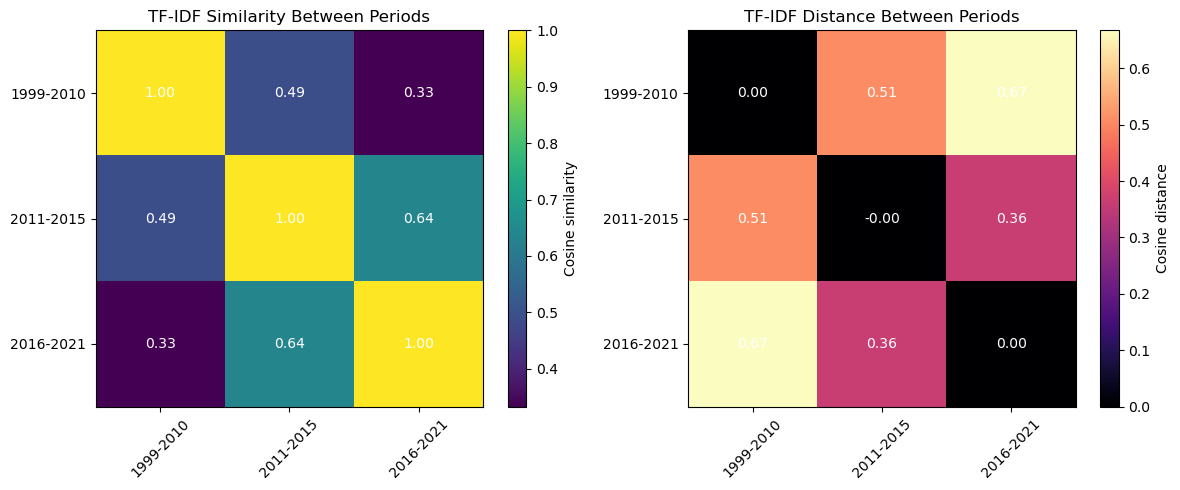

In [15]:
# from sklearn.metrics.pairwise import cosine_similarity
# 
# # calculate cosine similarity between different period


# Compute cosine similarity and cosine distance between periods
# based on their mean TF-IDF representations.
# Higher similarity means the periods are more similar in vocabulary use;
# larger distance means they are more different.
#
# The results are then stored as matrices and visualised as heatmaps

#The results show:
# - 2011–2015 and 2016–2021 are the most similar (similarity = 0.64)
# - 1999–2010 and 2016–2021 are the most different (distance = 0.67)
# - 1999–2010 and 2011–2015 are moderately related
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt

# Compute TF-IDF cosine similarity and distance
similarity_matrix = cosine_similarity(ngram_mean_tfidf)
distance_matrix = 1 - similarity_matrix

# Convert to DataFrame
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=ngram_mean_tfidf.index,
    columns=ngram_mean_tfidf.index
)

distance_df = pd.DataFrame(
    distance_matrix,
    index=ngram_mean_tfidf.index,
    columns=ngram_mean_tfidf.index
)

print("\n=== TF-IDF COSINE SIMILARITY BETWEEN PERIODS ===")
print(similarity_df)

print("\n=== TF-IDF COSINE DISTANCE BETWEEN PERIODS ===")
print(distance_df)

#painting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------- (1) Similarity ----------
ax1 = axes[0]
im1 = ax1.imshow(similarity_df, aspect="auto", cmap="viridis")
fig.colorbar(im1, ax=ax1, label="Cosine similarity")

ax1.set_xticks(range(len(similarity_df.columns)))
ax1.set_yticks(range(len(similarity_df.index)))
ax1.set_xticklabels(similarity_df.columns, rotation=45)
ax1.set_yticklabels(similarity_df.index)
ax1.set_title("TF-IDF Similarity Between Periods")

for i in range(len(similarity_df.index)):
    for j in range(len(similarity_df.columns)):
        ax1.text(j, i, f"{similarity_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")

# ---------- (2) Distance ----------
ax2 = axes[1]
im2 = ax2.imshow(distance_df, aspect="auto", cmap="magma")
fig.colorbar(im2, ax=ax2, label="Cosine distance")

ax2.set_xticks(range(len(distance_df.columns)))
ax2.set_yticks(range(len(distance_df.index)))
ax2.set_xticklabels(distance_df.columns, rotation=45)
ax2.set_yticklabels(distance_df.index)
ax2.set_title("TF-IDF Distance Between Periods")

for i in range(len(distance_df.index)):
    for j in range(len(distance_df.columns)):
        ax2.text(j, i, f"{distance_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")
plt.grid(False)
plt.tight_layout()
plt.show()


In [16]:
# from sklearn.metrics.pairwise import cosine_similarity
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# 
# # ===== 1. TF-IDF cosine similarity and distance =====
# similarity_matrix = cosine_similarity(ngram_mean_tfidf)
# distance_matrix = 1 - similarity_matrix
# 
# # Convert to DataFrame
# similarity_df = pd.DataFrame(
#     similarity_matrix,
#     index=ngram_mean_tfidf.index,
#     columns=ngram_mean_tfidf.index
# )
# 
# distance_df = pd.DataFrame(
#     distance_matrix,
#     index=ngram_mean_tfidf.index,
#     columns=ngram_mean_tfidf.index
# )
# 
# print("\n=== TF-IDF COSINE SIMILARITY BETWEEN PERIODS ===")
# print(similarity_df)
# 
# print("\n=== TF-IDF COSINE DISTANCE BETWEEN PERIODS ===")
# print(distance_df)
# 
# # ===== 2. Side-by-side seaborn heatmaps =====
# sns.set_theme(style="white")  # white background
# 
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 
# # ---------- (1) Similarity ----------
# sns.heatmap(
#     similarity_df,
#     ax=axes[0],
#     cmap="viridis",
#     annot=True,         # show values
#     fmt=".2f",          # two decimal places
#     linewidths=0,       # no grid lines between cells
#     cbar_kws={"label": "Cosine similarity"}
# )
# 
# axes[0].set_title("TF-IDF Similarity Between Periods")
# axes[0].set_xlabel("")
# axes[0].set_ylabel("")
# axes[0].tick_params(axis="x", rotation=45)
# axes[0].tick_params(axis="y", rotation=0)
# 
# # ---------- (2) Distance ----------
# sns.heatmap(
#     distance_df,
#     ax=axes[1],
#     cmap="magma",
#     annot=True,
#     fmt=".2f",
#     linewidths=0,
#     cbar_kws={"label": "Cosine distance"}
# )
# 
# axes[1].set_title("TF-IDF Distance Between Periods")
# axes[1].set_xlabel("")
# axes[1].set_ylabel("")
# axes[1].tick_params(axis="x", rotation=45)
# axes[1].tick_params(axis="y", rotation=0)
# 
# plt.tight_layout()
# plt.show()


In [17]:
#LDA (Dictionary + doc2bow + LdaModel+unigram) task


# Define a stricter stopword list for LDA,
# including both general English stopwords and common domain terms with low discriminative value.
# Then regenerate tokens for LDA input.


# from nltk.corpus import stopwords
english_stopwords = text.ENGLISH_STOP_WORDS
# base_stopwords = set(stopwords.words("english"))

lda_custom_stopwords = {
    "learning", "method", "methods", "model", "models", "data",
    "algorithm", "algorithms", "approach", "approaches",
    "problem", "problems", "paper", "result", "results",
    "using", "use", "used", "based",
    "real", "world", "state", "art",
    "show", "shows", "shown",
    "present", "presents", "presented",
    "propose", "proposed", "proposes",
    "introduce", "introduced",
    "demonstrate", "demonstrated",
    "task", "tasks", "performance",
    "new", "novel", "different",
    "also", "can", "may",
    "set", "case", "number",
    "function", "time"
}

lda_stopwords = english_stopwords .union(lda_custom_stopwords)

df["tokens"] = df["abstract"].apply(
    lambda x: preprocess_for_tfidf_lda(x, stop_words_set=lda_stopwords)
)

# Group tokenised documents by period,
# so that one LDA model can be trained for each time period separately.

grouped = df.groupby("period")["tokens"].apply(list)
 

In [18]:
# --- Cell 1: train one per-period LDA setting and return artifacts ---
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction import text

def run_period_lda(df, stopwords_set, num_topics=5, passes=10, random_state=42, no_below=5, no_above=0.5):
    df_tmp = df.copy()
    df_tmp["tokens_eval"] = df_tmp["abstract"].apply(
        lambda x: preprocess_for_tfidf_lda(x, stop_words_set=stopwords_set)
    )
    grouped = df_tmp.groupby("period")["tokens_eval"].apply(list)

    lda_inputs = {}
    lda_models = {}

    for period, texts in grouped.items():
        dictionary = Dictionary(texts)
        dictionary.filter_extremes(no_below=no_below, no_above=no_above)
        corpus = [dictionary.doc2bow(t) for t in texts]
        lda_inputs[period] = (texts, dictionary, corpus)

        lda = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=passes,
            random_state=random_state
        )
        lda_models[period] = lda

    return lda_inputs, lda_models

In [19]:
#build dictionary + corpus
# For each period, build:
# - a dictionary mapping words to ids
# - a bag-of-words corpus using doc2bow
# Rare and overly common words are filtered to reduce noise.
from gensim.corpora import Dictionary

lda_inputs = {}

for period, texts in grouped.items():
    dictionary = Dictionary(texts)
    
    # optional but recommended (filter extreme terms)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    
    corpus = [dictionary.doc2bow(text) for text in texts]
    
    lda_inputs[period] = (dictionary, corpus)
print(list(dictionary.token2id.items())[:5])


[('analysis', 0), ('application', 1), ('best', 2), ('defined', 3), ('described', 4)]


In [ ]:
#train lda
from gensim.models import LdaModel

lda_models = {}
#can do parameter changing task
# Train one LDA model for each period.
# Each model extracts 5 topics, allowing topic structures to be compared across time periods.
for period, (dictionary, corpus) in lda_inputs.items():
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=5,     
        passes=10,
        random_state=42
    )
    
    lda_models[period] = lda

In [ ]:
# --- Cell 2: compare metrics across two settings ---
import pandas as pd
from itertools import combinations
from gensim.models import CoherenceModel

# A = baseline stopwords (example: only english stopwords)
baseline_stopwords = text.ENGLISH_STOP_WORDS

# B = your stricter stopwords
strict_stopwords = lda_stopwords  

inputs_A, models_A = run_period_lda(df, baseline_stopwords)
inputs_B, models_B = run_period_lda(df, strict_stopwords)

def top_words_set(lda, topic_id, topn=10):
    return set([w for w, _ in lda.show_topic(topic_id, topn=topn)])

def avg_topic_jaccard_distance(lda, num_topics=5, topn=10):
    # A higher value indicates less overlap between topics (better distinctness)
    sets = [top_words_set(lda, k, topn=topn) for k in range(num_topics)]
    dists = []
    for a, b in combinations(sets, 2):
        j = len(a & b) / len(a | b) if (a | b) else 0.0
        dists.append(1 - j)
    return sum(dists) / len(dists) if dists else float("nan")

rows = []
for label, inputs, models in [("baseline", inputs_A, models_A), ("strict", inputs_B, models_B)]:
    for period in sorted(models.keys()):
        texts, dictionary, corpus = inputs[period]
        lda = models[period]

        vocab_size = len(dictionary)
        distinctness = avg_topic_jaccard_distance(lda, num_topics=5, topn=10)

        # optional coherence (C_v)
        try:
            cm = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence="c_v")
            coherence_cv = cm.get_coherence()
        except Exception:
            coherence_cv = float("nan")

        rows.append({
            "setting": label,
            "period": period,
            "vocab_size": vocab_size,
            "topic_distinctness_jaccard_dist": distinctness,
            "coherence_cv": coherence_cv
        })

metrics_df = pd.DataFrame(rows).sort_values(["period", "setting"]).reset_index(drop=True)
display(metrics_df)

,setting,period,vocab_size,topic_distinctness_jaccard_dist,coherence_cv
0,baseline,1999-2010,702,0.854704,0.240225
1,strict,1999-2010,670,0.973684,0.260372
2,baseline,2011-2015,2058,0.826634,0.345037
3,strict,2011-2015,2029,0.948099,0.383755
4,baseline,2016-2021,5598,0.848039,0.345560
5,strict,2016-2021,5573,0.938493,0.408514


In [ ]:
# Print the LDA topics and their top keywords for each period,
# so the main research themes in each time period can be interpreted manually.
for period, lda in lda_models.items():
    print(f"\n===== {period} =====")
    
    for i, topic in lda.show_topics(num_topics=5, num_words=10, formatted=True):
        print(f"Topic {i}: {topic}")
        
# Per-period LDA topics are listed above—each period has its own numbering. Compare periods by
# reading the printed keywords (e.g. when neural / graph / RL / federated language becomes more central),
# not by assuming the same topic id means the same theme across periods.


===== 1999-2010 =====
Topic 0: 0.021*"prediction" + 0.016*"loss" + 0.013*"class" + 0.013*"expert" + 0.011*"decision" + 0.010*"bound" + 0.010*"example" + 0.010*"information" + 0.008*"complexity" + 0.008*"classifier"
Topic 1: 0.021*"class" + 0.019*"measure" + 0.018*"distribution" + 0.015*"rule" + 0.015*"tree" + 0.014*"error" + 0.013*"language" + 0.012*"stochastic" + 0.012*"bayes" + 0.011*"probability"
Topic 2: 0.015*"accuracy" + 0.014*"technique" + 0.013*"mean" + 0.012*"strategy" + 0.011*"classification" + 0.011*"variable" + 0.011*"bound" + 0.011*"prior" + 0.011*"feature" + 0.010*"bayesian"
Topic 3: 0.016*"clustering" + 0.013*"convex" + 0.013*"distribution" + 0.012*"estimate" + 0.011*"group" + 0.011*"dimension" + 0.010*"optimization" + 0.009*"existing" + 0.009*"distance" + 0.008*"risk"
Topic 4: 0.025*"kernel" + 0.018*"log" + 0.016*"bound" + 0.015*"non" + 0.015*"matrix" + 0.013*"complex" + 0.013*"margin" + 0.013*"application" + 0.009*"machine" + 0.009*"svm"

===== 2011-2015 =====
Topic 0

In [ ]:
#LDA (Dictionary + doc2bow + LdaModel+bigram) task
# LDA (Bigram version)
#Use a bigram-based LDA pipeline.
# A phrase model is first trained on unigram tokens,
# then common word pairs (e.g. neural_network, feature_selection)
# are added to the text representation so that LDA can capture more specific topics.
from sklearn.feature_extraction import text
from gensim.corpora import Dictionary
from gensim.models import LdaModel, Phrases
from gensim.models.phrases import Phraser

english_stopwords = text.ENGLISH_STOP_WORDS

lda_custom_stopwords = {
    "learning", "method", "methods", "model", "models", "data",
    "algorithm", "algorithms", "approach", "approaches",
    "problem", "problems", "paper", "result", "results",
    "using", "use", "used", "based",
    "real", "world", "state", "art",
    "show", "shows", "shown",
    "present", "presents", "presented",
    "propose", "proposed", "proposes",
    "introduce", "introduced",
    "demonstrate", "demonstrated",
    "task", "tasks", "performance",
    "new", "novel", "different",
    "also", "can", "may",
    "set", "case", "number",
    "function", "time"
}

lda_stopwords = english_stopwords.union(lda_custom_stopwords)

# 1. unigram tokens
df["tokens"] = df["abstract"].apply(
    lambda x: preprocess_for_tfidf_lda(x, stop_words_set=lda_stopwords)
)

# 2. train bigram
# Train a bigram model on all documents
# to detect frequently co-occurring word pairs and merge them into phrases.
all_texts = df["tokens"].tolist()

bigram = Phrases(
    all_texts,
    min_count=2,
    threshold=3
)

bigram_mod = Phraser(bigram)

# 3. bigram tokens
# Convert unigram tokens into bigram-enhanced tokens,
# e.g. "latent variable" may become "latent_variable".
df["tokens_bigram"] = df["tokens"].apply(lambda x: bigram_mod[x])

# Check whether bigrams are present in the vocabulary
print(df["tokens"].iloc[0][:20])
print(df["tokens_bigram"].iloc[0][:20])

# 4. Split by period (use tokens_bigram here)
grouped_bigram = df.groupby("period")["tokens_bigram"].apply(list)
# print(grouped_bigram["1999-2010"][:2])

# 5. build dictionary + corpus
lda_inputs_bigram = {}

for period, texts in grouped_bigram.items():
    dictionary = Dictionary(texts)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(text) for text in texts]
    lda_inputs_bigram[period] = (dictionary, corpus)
#
# print(list(dictionary.token2id.items())[:10])

# 6. train LDA
lda_models_bigram = {}

for period, (dictionary, corpus) in lda_inputs_bigram.items():
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=7,
        passes=10,
        random_state=42,
    )
    lda_models_bigram[period] = lda



['uncovers', 'explores', 'close', 'relationship', 'monte', 'carlo', 'optimization', 'parametrized', 'integral', 'mco', 'parametric', 'machine', 'blackbox', 'oracle', 'optimization', 'make', 'contribution', 'prove', 'mco', 'mathematically']
['uncovers', 'explores', 'close_relationship', 'monte_carlo', 'optimization', 'parametrized', 'integral', 'mco', 'parametric', 'machine', 'blackbox', 'oracle', 'optimization', 'make_contribution', 'prove', 'mco', 'mathematically', 'identical', 'broad_class', 'identity']


In [ ]:
# 7. output topic

# After adding bigrams, more specific phrase-level terms appear in the topics,
# such as latent_variable, feature_selection, and neural_network.
# This suggests that the bigram version captures methods and technical concepts more clearly than the unigram version.
for period, lda in lda_models_bigram.items():
    print(f"\n===== {period} (bigram) =====")
    for i, topic in lda.show_topics(num_topics=7, num_words=10, formatted=True):
        print(f"Topic {i}: {topic}")


===== 1999-2010 (bigram) =====
Topic 0: 0.032*"loss" + 0.018*"hybrid" + 0.015*"classifier" + 0.015*"classification" + 0.014*"matrix" + 0.012*"guarantee" + 0.012*"function" + 0.012*"clustering" + 0.011*"setting" + 0.010*"set"
Topic 1: 0.029*"example" + 0.014*"expert" + 0.014*"setting" + 0.014*"dimension" + 0.013*"solution" + 0.011*"large" + 0.011*"estimate" + 0.011*"distributed" + 0.011*"mean" + 0.010*"possible"
Topic 2: 0.021*"technique" + 0.019*"network" + 0.016*"classification" + 0.016*"machine" + 0.015*"classifier" + 0.013*"distribution" + 0.012*"error" + 0.012*"framework" + 0.012*"sample" + 0.011*"attribute"
Topic 3: 0.029*"rule" + 0.017*"prediction" + 0.016*"cluster" + 0.014*"classifier" + 0.014*"bound" + 0.013*"factor" + 0.011*"consider" + 0.011*"database" + 0.010*"classification" + 0.010*"user"
Topic 4: 0.022*"class" + 0.018*"prediction" + 0.017*"tree" + 0.016*"strategy" + 0.013*"application" + 0.012*"observation" + 0.011*"regularization" + 0.011*"prove" + 0.011*"signal" + 0.01

In [ ]:
# Train a global LDA model on all documents instead of separate models per period.
#
# Purpose:
# - obtain a shared topic space (global topics)
# - use it as a common reference across periods
# - enable comparison of topic distributions over time within the same topic set
# Note: topics from separate LDA models are not directly comparable,
# so a global LDA provides a shared reference for analysing topic evolution over time.
from gensim.corpora import Dictionary
from gensim.models import LdaModel


all_texts = df["tokens_bigram"].tolist()

global_dictionary = Dictionary(all_texts)
global_dictionary.filter_extremes(no_below=10, no_above=0.3)

global_corpus = [global_dictionary.doc2bow(text) for text in all_texts]

global_lda = LdaModel(
    corpus=global_corpus,
    id2word=global_dictionary,
    num_topics=10,   # Parameter tuning experiments can be conducted
    passes=10,
    random_state=42
)



In [ ]:
# see topics
for i, topic in global_lda.show_topics(num_topics=12, num_words=10, formatted=True):
    print(f"Topic {i}: {topic}")
# Global LDA topic ids are arbitrary: interpret each "Topic i" only from the keywords
# printed by show_topics() above (do not assume e.g. "Topic 1 = deep learning" by number).
#
# Typical workflow: skim all topics for recurring families (classification, Bayesian
# statistics, optimization, neural/deep learning, graphs, RL/bandits, etc.), then relate
# period-specific mixtures to those keywords—not to a fixed id→theme map.

Topic 0: 0.033*"network" + 0.028*"training" + 0.019*"neural_network" + 0.013*"architecture" + 0.010*"deep" + 0.010*"deep_neural" + 0.010*"layer" + 0.008*"parameter" + 0.006*"gradient" + 0.006*"accuracy"
Topic 1: 0.023*"policy" + 0.015*"reward" + 0.014*"agent" + 0.013*"setting" + 0.012*"online" + 0.010*"action" + 0.009*"environment" + 0.008*"reinforcement" + 0.008*"regret" + 0.008*"exploration"
Topic 2: 0.021*"patient" + 0.015*"attack" + 0.014*"risk" + 0.013*"explanation" + 0.010*"disease" + 0.009*"gan" + 0.009*"clinical" + 0.008*"treatment" + 0.008*"prediction" + 0.008*"gans"
Topic 3: 0.015*"kernel" + 0.014*"matrix" + 0.012*"sample" + 0.007*"linear" + 0.006*"point" + 0.006*"sparse" + 0.006*"structure" + 0.006*"input" + 0.006*"adversarial_training" + 0.006*"space"
Topic 4: 0.022*"representation" + 0.010*"space" + 0.008*"dynamic" + 0.008*"structure" + 0.007*"neural" + 0.006*"network" + 0.006*"domain" + 0.005*"learn" + 0.005*"work" + 0.005*"learned"
Topic 5: 0.010*"optimization" + 0.010*"

In [ ]:
# Helpers for global LDA: document → topic vector and per-period sample plots.
# (These were referenced below but missing from this notebook; mirrored from course template.)
import numpy as np
import matplotlib.pyplot as plt


def convert_theta_sparse_to_dense(theta_d_sparse, num_topics):
    theta_d = np.zeros(num_topics)
    for topic_id, prob in theta_d_sparse:
        theta_d[topic_id] = prob
    return theta_d


def get_topic_dists_in_period(
    period_name, df, lda_model, dictionary, token_col="tokens_bigram", max_num_docs=10
):
    subset = df[df["period"] == period_name].head(max_num_docs)
    thetas = []
    for tokens in subset[token_col]:
        bow_vector = dictionary.doc2bow(tokens)
        theta_d = lda_model.get_document_topics(bow_vector, minimum_probability=0)
        thetas.append(theta_d)
    return thetas


def plot_theta(thetas, d, num_docs, num_topics):
    plt.subplot((num_docs + 2) // 3, 3, d + 1)
    theta_d = convert_theta_sparse_to_dense(thetas[d], num_topics)
    dominant_topic = int(np.argmax(theta_d))
    plt.bar(np.arange(num_topics), theta_d)
    plt.xticks(np.arange(num_topics))
    plt.ylim(0, 1)
    plt.title(f"Doc {d + 1} (Top topic: {dominant_topic})")

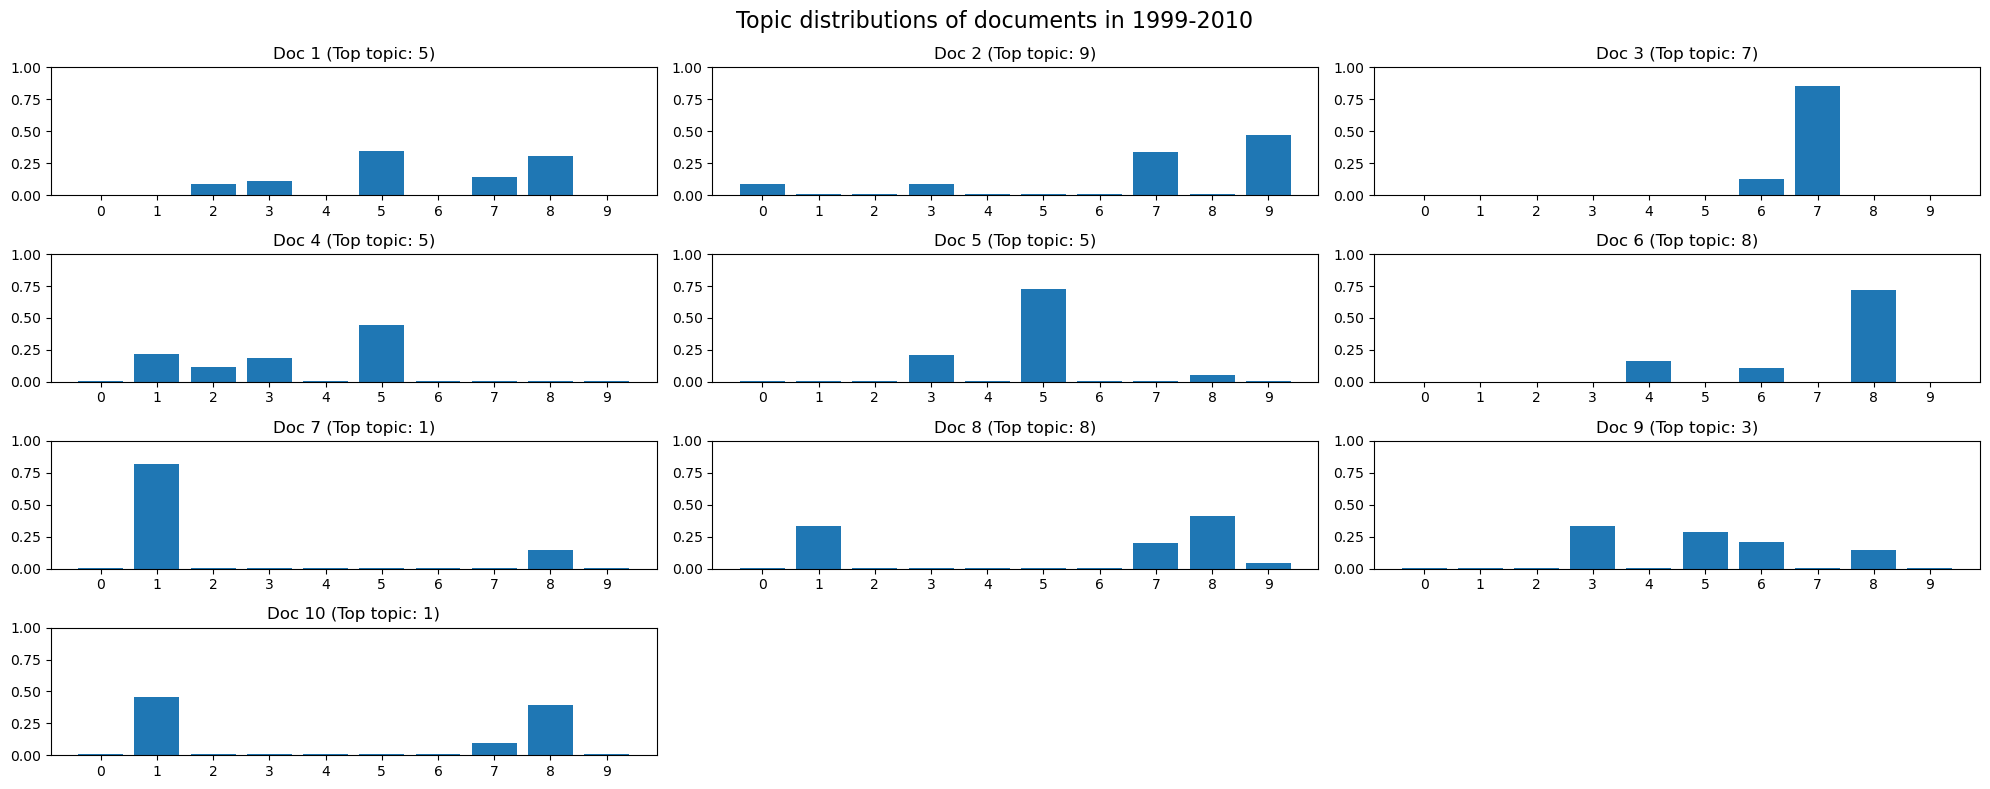

In [ ]:
period_name = "1999-2010"
num_topics = global_lda.num_topics

thetas = get_topic_dists_in_period(period_name, df, global_lda, global_dictionary, token_col="tokens_bigram", max_num_docs=10)

plt.figure(figsize=(20, 8))
num_docs = len(thetas)

for d in range(num_docs):
    plot_theta(thetas, d, num_docs, num_topics)

plt.suptitle(f"Topic distributions of documents in {period_name}", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Print the LDA topics and their top keywords for each period,
# so the main research themes in each time period can be interpreted manually.
for period, lda in lda_models.items():
    print(f"\n===== {period} =====")
    
    for i, topic in lda.show_topics(num_topics=5, num_words=10, formatted=True):
        print(f"Topic {i}: {topic}")
        
# Per-period LDA topics are listed above—each period has its own numbering. Compare periods by
# reading the printed keywords (e.g. when neural / graph / RL / federated language becomes more central),
# not by assuming the same topic id means the same theme across periods.


===== 1999-2010 =====
Topic 0: 0.021*"prediction" + 0.016*"loss" + 0.013*"class" + 0.013*"expert" + 0.011*"decision" + 0.010*"bound" + 0.010*"example" + 0.010*"information" + 0.008*"complexity" + 0.008*"classifier"
Topic 1: 0.021*"class" + 0.019*"measure" + 0.018*"distribution" + 0.015*"rule" + 0.015*"tree" + 0.014*"error" + 0.013*"language" + 0.012*"stochastic" + 0.012*"bayes" + 0.011*"probability"
Topic 2: 0.015*"accuracy" + 0.014*"technique" + 0.013*"mean" + 0.012*"strategy" + 0.011*"classification" + 0.011*"variable" + 0.011*"bound" + 0.011*"prior" + 0.011*"feature" + 0.010*"bayesian"
Topic 3: 0.016*"clustering" + 0.013*"convex" + 0.013*"distribution" + 0.012*"estimate" + 0.011*"group" + 0.011*"dimension" + 0.010*"optimization" + 0.009*"existing" + 0.009*"distance" + 0.008*"risk"
Topic 4: 0.025*"kernel" + 0.018*"log" + 0.016*"bound" + 0.015*"non" + 0.015*"matrix" + 0.013*"complex" + 0.013*"margin" + 0.013*"application" + 0.009*"machine" + 0.009*"svm"

===== 2011-2015 =====
Topic 0

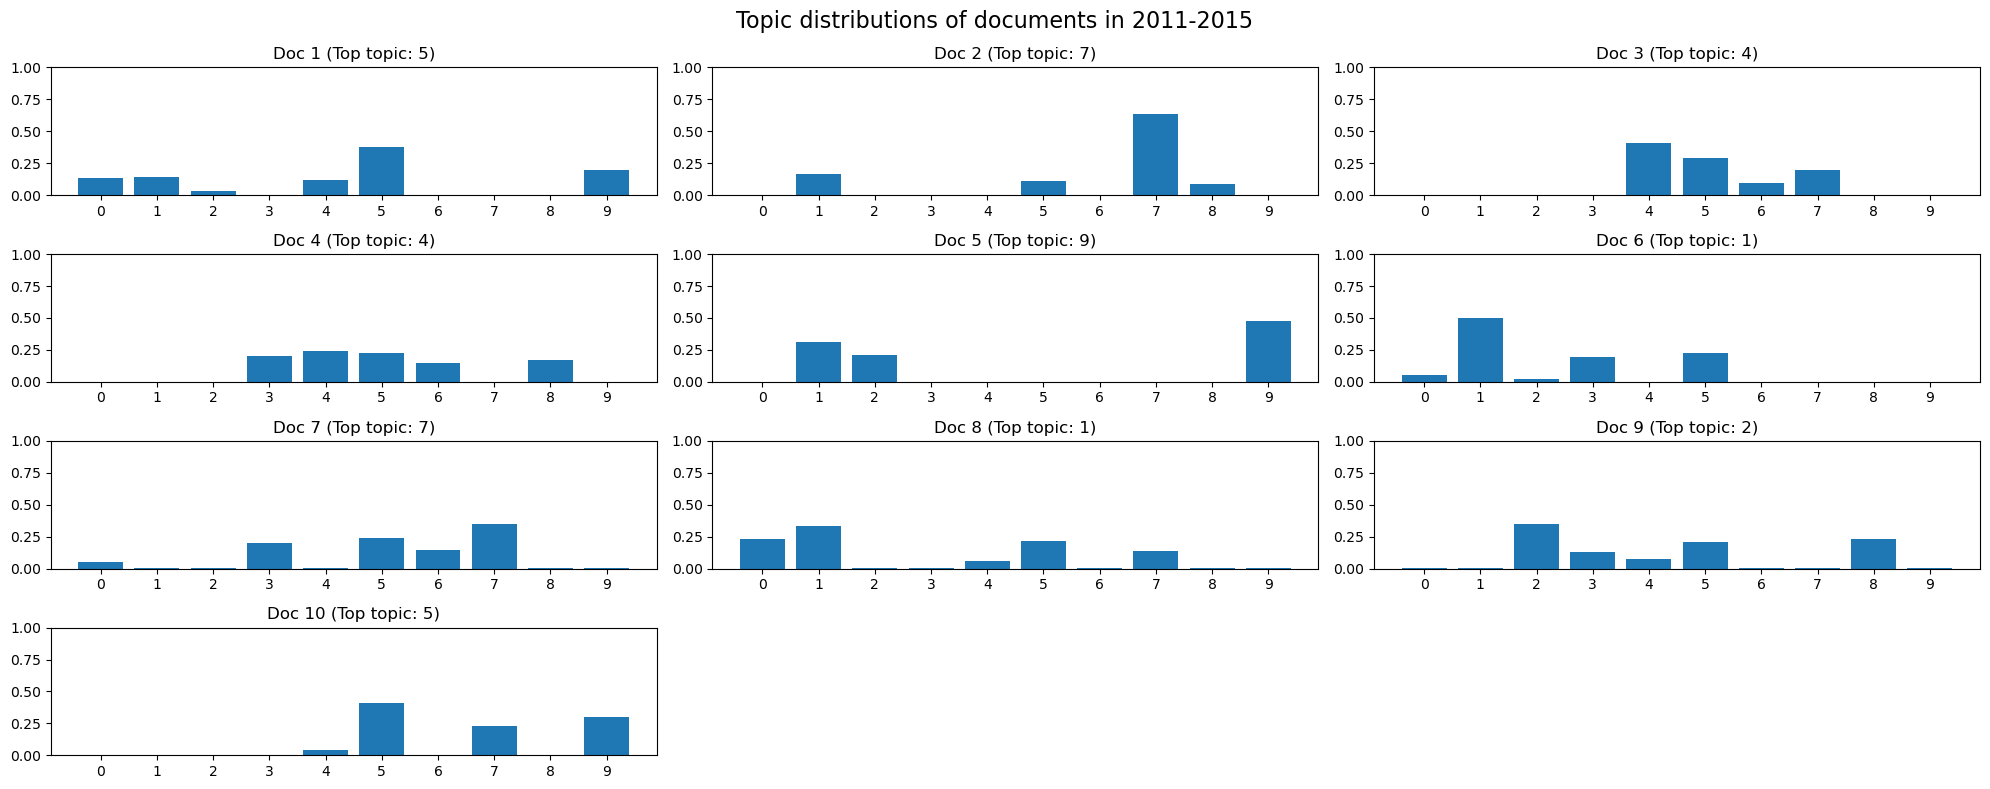

In [ ]:
# Must match assign_period() labels in df["period"] (only three bins exist).
period_name = "2011-2015"  # was "2007-2012" — no rows matched, so plot had 0 axes
num_topics = global_lda.num_topics

thetas = get_topic_dists_in_period(period_name, df, global_lda, global_dictionary, token_col="tokens_bigram", max_num_docs=10)

plt.figure(figsize=(20, 8))
num_docs = len(thetas)

for d in range(num_docs):
    plot_theta(thetas, d, num_docs, num_topics)

plt.suptitle(f"Topic distributions of documents in {period_name}", fontsize=16)
plt.tight_layout()
plt.show()

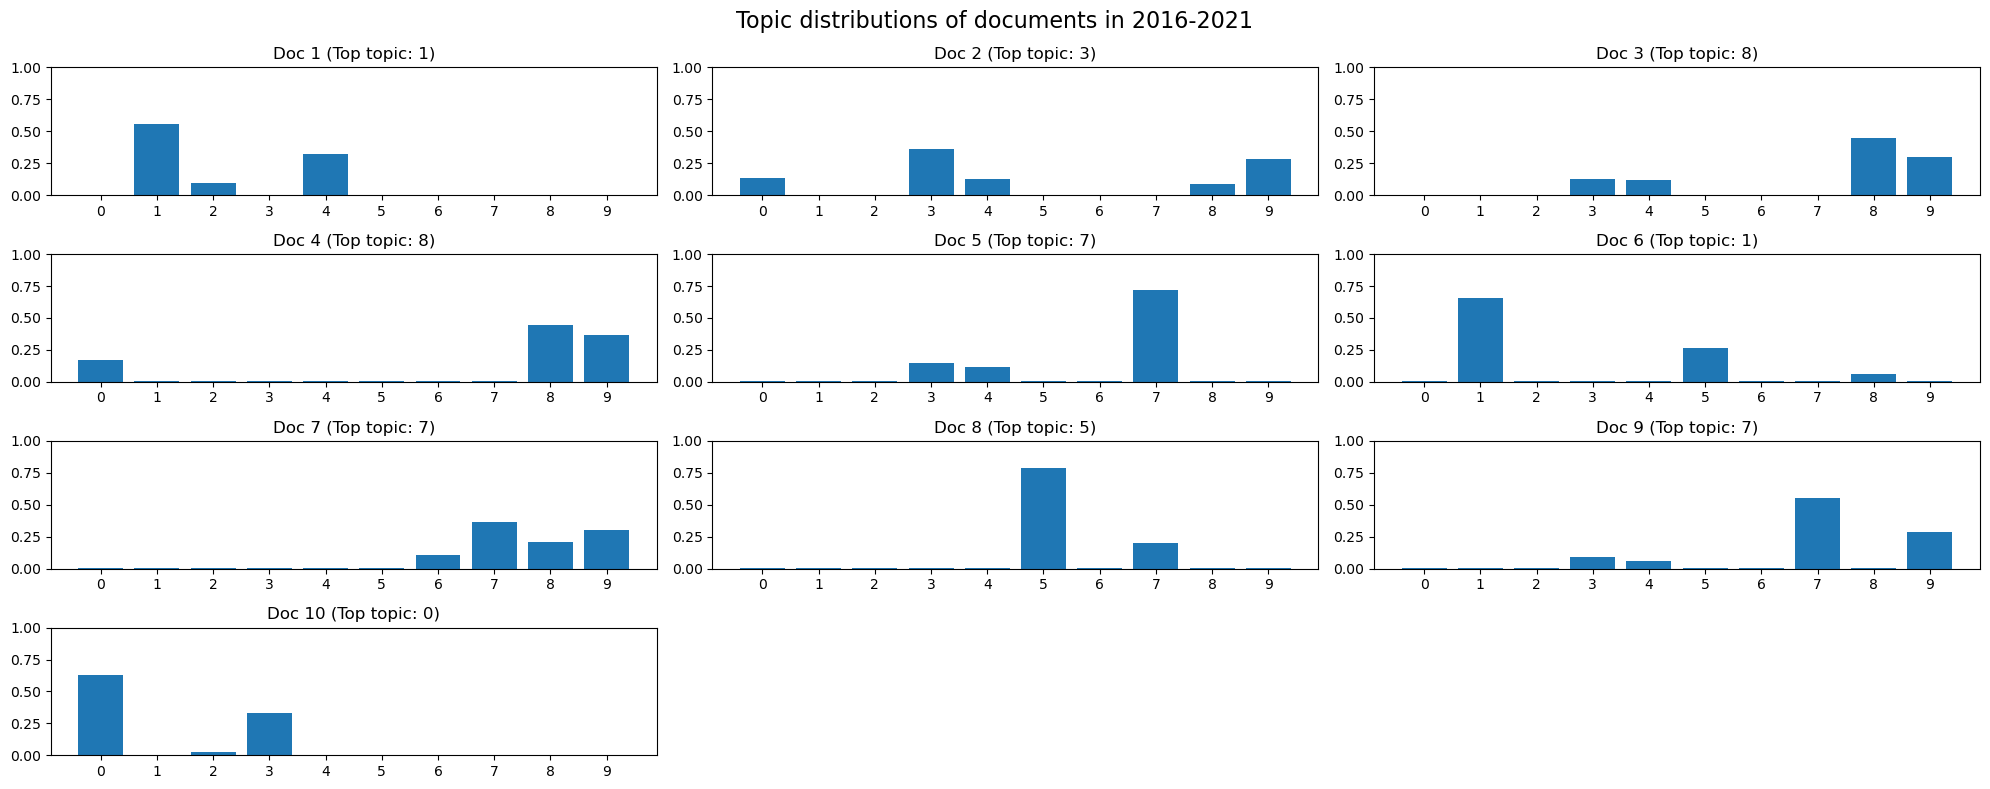

In [ ]:
period_name = "2016-2021"
num_topics = global_lda.num_topics

thetas = get_topic_dists_in_period(period_name, df, global_lda, global_dictionary, token_col="tokens_bigram", max_num_docs=10)

plt.figure(figsize=(20, 8))
num_docs = len(thetas)

for d in range(num_docs):
    plot_theta(thetas, d, num_docs, num_topics)

plt.suptitle(f"Topic distributions of documents in {period_name}", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Compute per-period topics
# Compute the mean topic distribution for each period.
# Steps:
# 1. infer the topic probability distribution of each document using the global LDA model
# 2. average these topic distributions within each period
#
# This gives:
# - the overall topic profile of each period in the shared global topic space
# - which topics are more prominent in each period
def get_period_mean_topics(df, lda_model, dictionary, periods, token_col="tokens_bigram", num_topics=global_lda.num_topics):
    mean_thetas = np.zeros((len(periods), num_topics))

    for i, period in enumerate(periods):
        subset = df[df["period"] == period]

        thetas = []
        for tokens in subset[token_col]:
            bow_vector = dictionary.doc2bow(tokens)
            theta_sparse = lda_model[bow_vector]
            theta_dense = convert_theta_sparse_to_dense(theta_sparse, num_topics)
            thetas.append(theta_dense)

        mean_theta = np.mean(thetas, axis=0)
        mean_thetas[i] = mean_theta

    return mean_thetas


periods = sorted(df["period"].unique())
num_topics = global_lda.num_topics

mean_thetas = get_period_mean_topics(
    df=df,
    lda_model=global_lda,
    dictionary=global_dictionary,
    periods=periods,
    token_col="tokens_bigram",
    num_topics=num_topics
)

print(mean_thetas.shape)
print(mean_thetas)


(3, 10)
[[0.03485419 0.11762536 0.02687978 0.12461679 0.07137235 0.21351917
  0.05089874 0.10957233 0.13057764 0.10074306]
 [0.08470739 0.11731379 0.02804328 0.12336611 0.08331683 0.16260125
  0.06445573 0.1241539  0.09117778 0.10560133]
 [0.14252289 0.07782518 0.03795786 0.06742879 0.09254675 0.10475377
  0.11047806 0.18757747 0.08215915 0.08513217]]


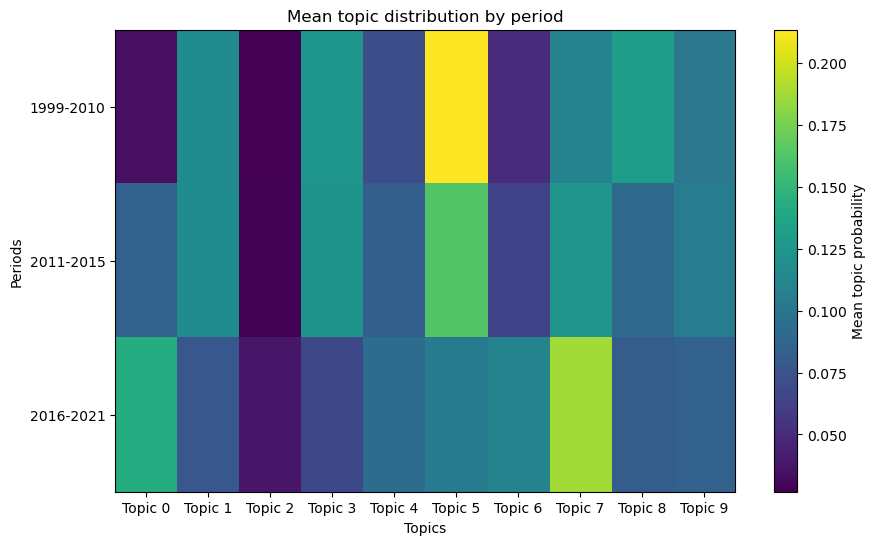

In [ ]:
plt.figure(figsize=(10, 6))
plt.grid(False)
plt.imshow(mean_thetas, aspect="auto")
plt.colorbar(label="Mean topic probability")
plt.yticks(range(len(periods)), periods)
plt.xticks(range(num_topics), [f"Topic {i}" for i in range(num_topics)])
plt.xlabel("Topics")
plt.ylabel("Periods")
plt.title("Mean topic distribution by period")
plt.show()
# The heatmap encodes mean LDA topic probability by period (darker = higher weight for
# that topic column in that row). Each column is an arbitrary topic id—name it using
# lda.show_topics(), then compare which ids brighten or dim across periods.
# Overall, profiles differ by period rather than staying identical.


=== LDA COSINE SIMILARITY BETWEEN PERIODS ===
           1999-2010  2011-2015  2016-2021
1999-2010   1.000000   0.970995   0.827567
2011-2015   0.970995   1.000000   0.918389
2016-2021   0.827567   0.918389   1.000000


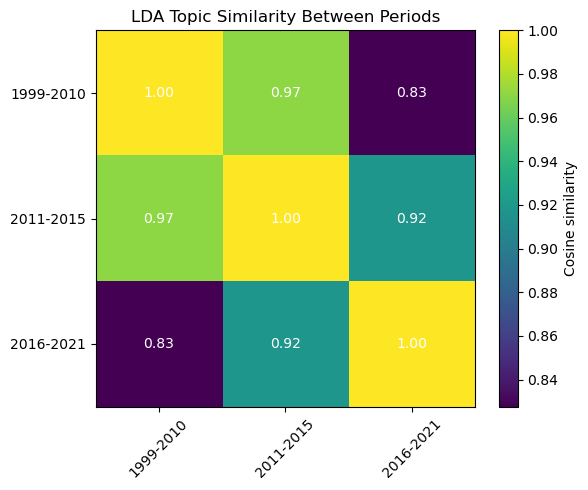

In [ ]:
# LDA similarity matrix
# Compute cosine similarity between periods
# based on their mean topic distributions (mean_thetas).
#
# This measures similarity in terms of topic composition,
# rather than raw word overlap.
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cosine similarity from mean topic distribution per period
lda_similarity_matrix = cosine_similarity(mean_thetas)

# 2. Wrap in DataFrames for readability
lda_similarity_df = pd.DataFrame(
    lda_similarity_matrix,
    index=periods,
    columns=periods
)

print("\n=== LDA COSINE SIMILARITY BETWEEN PERIODS ===")
print(lda_similarity_df)

# 3. Plot heatmaps
plt.figure(figsize=(6, 5))
plt.grid(False)
plt.imshow(lda_similarity_df, aspect="auto", cmap="viridis")
plt.colorbar(label="Cosine similarity")
plt.xticks(range(len(periods)), periods, rotation=45)
plt.yticks(range(len(periods)), periods)
plt.title("LDA Topic Similarity Between Periods")

# 4. Annotate heatmap cells
for i in range(len(periods)):
    for j in range(len(periods)):
        plt.text(j, i, f"{lda_similarity_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

# Compute cosine similarity between periods
# based on their mean topic distributions (mean_thetas).
#
# This measures similarity in terms of topic composition,
# rather than raw word overlap.



=== LDA COSINE DISTANCE BETWEEN PERIODS ===
           1999-2010  2011-2015  2016-2021
1999-2010   0.000000   0.029005   0.172433
2011-2015   0.029005   0.000000   0.081611
2016-2021   0.172433   0.081611   0.000000


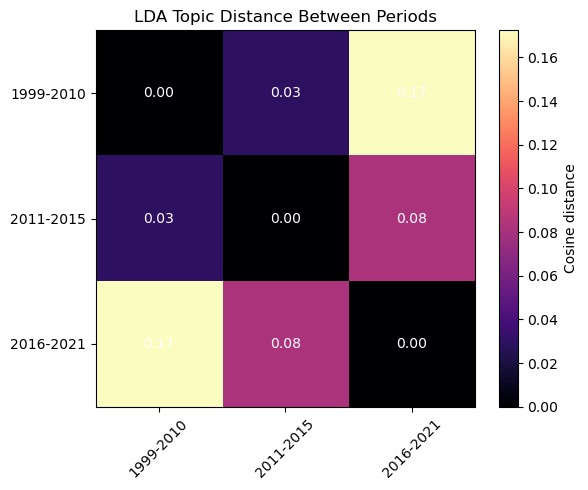

In [ ]:
# LDA period distance matrix
# Compute cosine distance between periods based on mean topic distributions.
# Defined as:
# cosine distance = 1 - cosine similarity
#
# Interpretation:
# - closer to 0 → more similar
# - larger values → more different
lda_distance_matrix = 1 - cosine_similarity(mean_thetas)

lda_distance_df = pd.DataFrame(
    lda_distance_matrix,
    index=periods,
    columns=periods
)

print("\n=== LDA COSINE DISTANCE BETWEEN PERIODS ===")
print(lda_distance_df)

plt.figure(figsize=(6, 5))
plt.grid(False)
plt.imshow(lda_distance_df, aspect="auto", cmap="magma")
plt.colorbar(label="Cosine distance")
plt.xticks(range(len(periods)), periods, rotation=45)
plt.yticks(range(len(periods)), periods)
plt.title("LDA Topic Distance Between Periods")

for i in range(len(periods)):
    for j in range(len(periods)):
        plt.text(j, i, f"{lda_distance_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")

plt.tight_layout()
plt.show()


In [ ]:
#BERTopic
from bertopic import BERTopic
# Apply BERTopic to the full corpus.
# The input is clean_text_embed, which preserves more semantic information
# and is more suitable for embedding-based topic modelling.
# Unlike LDA, BERTopic uses text embeddings to model semantic similarity,
# making it better suited for capturing documents that are semantically related
# even if they do not share the same surface words.
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np

texts = df["clean_text_embed"].tolist()
print(len(texts))
print(texts[0][:300])

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# embeddings = embedding_model.encode(texts)
# 
# print(embeddings.shape)

7015
This paper uncovers and explores the close relationship between Monte Carlo Optimization of a parametrized integral (MCO), Parametric machine-Learning (PL), and `blackbox' or `oracle'-based optimization (BO). We make four contributions. First, we prove that MCO is mathematically identical to a broad


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Common on Mac/Jupyter: silent kernel crash when UMAP conflicts with OpenMP.
# Limit threads before importing numerical libs; set calculate_probabilities=False to reduce memory.
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP

# Define a CountVectorizer for BERTopic
# to generate representative keywords for each topic.
# Unigrams and bigrams are included to make topic words more specific.
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)
#Parameter tuning experiments can be conducted
#ngram_range=(1, 2)
# A (1,1) words only (word-level)
# B (1,2) words + phrases (phrase-level)
# C (1,2), min_df=10 high-frequency phrases (filtered)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
    n_jobs=1,
    low_memory=True,
)

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    verbose=True,
    calculate_probabilities=False,
    min_topic_size=50,  # Parameter tuning experiments can be conducted
)
# Run upstream cells first to build `df`. BERTopic uses lightly cleaned sentence text for embeddings.
texts = df["clean_text_embed"].astype(str).tolist()
topics, probs = topic_model.fit_transform(texts)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-03 02:28:21,957 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-05-03 02:28:55,839 - BERTopic - Embedding - Completed ✓
2026-05-03 02:28:55,840 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-05-03 02:29:08,021 - BERTopic - Dimensionality - Completed ✓
2026-05-03 02:29:08,022 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 02:29:08,146 - BERTopic - Cluster - Completed ✓
2026-05-03 02:29:08,149 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 02:29:08,734 - BERTopic - Representation - Completed ✓


In [ ]:
# Retrieve summary information of all topics
# (including topic id and document counts)
# 4. save results
df["bertopic_topic"] = topics
# probs: if calculate_probabilities=True each row is a vector; if False may be scalar or None
def _bertopic_max_prob(p):
    if p is None:
        return np.nan
    arr = np.asarray(p)
    if arr.ndim == 0:
        return float(arr)
    if arr.size == 0:
        return np.nan
    return float(arr.max())


if probs is None:
    df["bertopic_prob"] = np.nan
else:
    df["bertopic_prob"] = [_bertopic_max_prob(p) for p in probs]

# 5.topic info
topic_info = topic_model.get_topic_info()
# print(topic_info.head(15))
for topic_id in topic_info["Topic"].head(10):
    print(f"\n===== Topic {topic_id} =====")
    print(topic_model.get_topic(topic_id))
    
# 5b. visualize topics
# Each circle represents a topic:
# - circle size: number of documents in the topic (importance)
# - distance between circles: semantic difference between topics
fig_topics = topic_model.visualize_topics()
fig_topics.show()
# Topic meanings for this fit (always re-verify with topic_model.get_topic(id) after re-training):
# - Topic -1: outliers / noise (generic words: data, model, method, …)
# - Topic 0: deep neural networks & training
# - Topic 1: reinforcement learning
# - Topic 2: graph neural networks (GNN)
# - Topic 3: healthcare / clinical prediction
# - Topic 4: multi-armed bandits / online optimization
# - Topic 5: generative models & GANs
# - Topic 6: federated learning & privacy
# - Topic 7: adversarial robustness & attacks
# - Topic 8: spatiotemporal / traffic forecasting
#
# These line up with common ML research strands on arXiv; ids are still model-specific.


# Compared to LDA, BERTopic produces more specific and semantically coherent topics,
# as it is based on embeddings rather than word frequency.



===== Topic -1 =====
[('data', 0.02013006735194927), ('learning', 0.01862445899977339), ('model', 0.01315744382335799), ('based', 0.012125151605771826), ('models', 0.01154913899867994), ('paper', 0.010754087085978742), ('methods', 0.010644159964015345), ('algorithm', 0.01050571454281007), ('performance', 0.010427937075779548), ('method', 0.010322340468564352)]

===== Topic 0 =====
[('neural', 0.026834133284567453), ('networks', 0.026307367563402354), ('training', 0.02089269661755212), ('deep', 0.020693212252267085), ('network', 0.020182512730353458), ('neural networks', 0.019650531745845867), ('gradient', 0.01634638996848715), ('learning', 0.015029920833437817), ('deep learning', 0.011662104140382776), ('performance', 0.011491079861314661)]

===== Topic 1 =====
[('policy', 0.04054462288691043), ('reinforcement', 0.03418146779344446), ('reinforcement learning', 0.034074729394076485), ('rl', 0.0331557430376454), ('learning', 0.028850626149908448), ('agent', 0.021251124122485445), ('stat

In [ ]:
# 6. topic distribution by period
topic_period_table = pd.crosstab(df["period"], df["bertopic_topic"], normalize="index")
print(topic_period_table)
# Compute topic distribution for each period (normalized proportions).
# Rows = periods
# Columns = topics
# Values = proportion of documents belonging to each topic

# Interpret the printed topic_period_table using topic_model.get_topic(id) (see list above).
# Read trends from the numeric proportions (which topic ids rise or fall by row), not from
# guessing ids—e.g. in this notebook Topic 2 is GNN and Topic 5 is generative/GAN, not
# "clustering" vs "deep learning" by number alone.
#
# You can comment on topic -1 (outliers) share per period only after checking its column.
#
# At a high level, BERTopic often surfaces modern strands (deep nets, GNN, generative,
# federated, etc.) with different strengths by period; exact rankings come from this table.
#
# This complements LDA: embeddings tend to yield tighter semantic groupings than raw counts.

bertopic_topic       -1         0         1         2         3         4   \
period                                                                       
1999-2010       0.524590  0.032787  0.061475  0.016393  0.008197  0.032787   
2011-2015       0.411479  0.075875  0.057393  0.032101  0.019455  0.053502   
2016-2021       0.280341  0.117360  0.106565  0.085844  0.048407  0.029601   

bertopic_topic        5         6         7         8   ...        16  \
period                                                  ...             
1999-2010       0.008197  0.000000  0.000000  0.004098  ...  0.000000   
2011-2015       0.021401  0.007782  0.001946  0.006809  ...  0.007782   
2016-2021       0.033780  0.036218  0.028731  0.023681  ...  0.016716   

bertopic_topic        17        18        19        20        21        22  \
period                                                                       
1999-2010       0.004098  0.012295  0.040984  0.008197  0.020492  0.000000   
2011-2015

=== Cosine Similarity ===
period     1999-2010  2011-2015  2016-2021
period                                    
1999-2010   1.000000   0.983472   0.864216
2011-2015   0.983472   1.000000   0.915510
2016-2021   0.864216   0.915510   1.000000

=== Cosine Distance ===
period        1999-2010     2011-2015  2016-2021
period                                          
1999-2010 -8.881784e-16  1.652772e-02   0.135784
2011-2015  1.652772e-02 -6.661338e-16   0.084490
2016-2021  1.357844e-01  8.448966e-02   0.000000


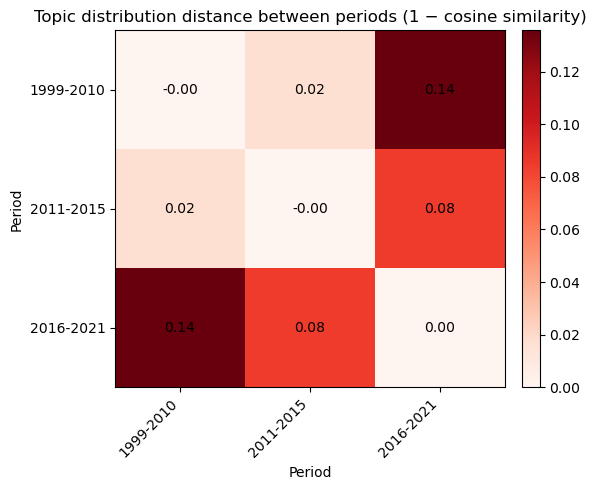

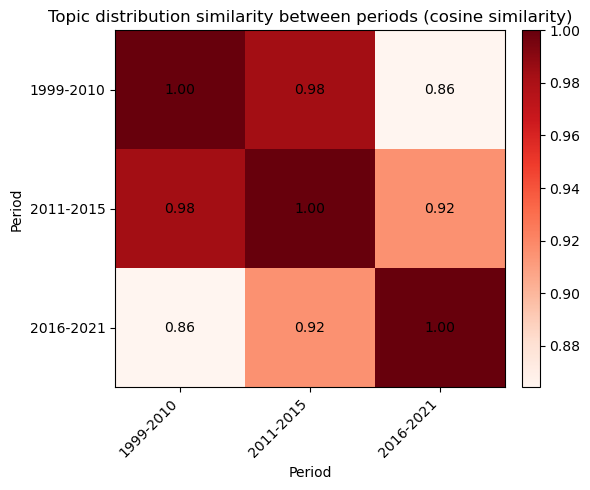

In [ ]:
# Compute similarity and distance between periods
# based on BERTopic topic distributions (topic_period_table).
#
# Each row represents a topic distribution vector for a period,
# and cosine similarity is used to measure similarity.


# 7. Distance and similarity matrices for topic distributions across periods
# Pairwise distance between period topic distributions
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# topic_period_table: rows=periods, columns=topics, values=proportions
sim_matrix = cosine_similarity(topic_period_table.values)
dist_matrix = 1 - sim_matrix

# Convert to DataFrame for display
sim_df = pd.DataFrame(
    sim_matrix,
    index=topic_period_table.index,
    columns=topic_period_table.index
)

dist_df = pd.DataFrame(
    dist_matrix,
    index=topic_period_table.index,
    columns=topic_period_table.index
)

print("=== Cosine Similarity ===")
print(sim_df)

print("\n=== Cosine Distance ===")
print(dist_df)

# Heatmaps (matplotlib only — works without seaborn)
import matplotlib.pyplot as plt
import numpy as np


def plot_period_matrix_heatmap(df, title, fmt=".2f", cmap="Reds"):
    arr = df.values.astype(float)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(arr, cmap=cmap, aspect="auto")
    ax.set_xticks(np.arange(arr.shape[1]))
    ax.set_yticks(np.arange(arr.shape[0]))
    ax.set_xticklabels(df.columns, rotation=45, ha="right")
    ax.set_yticklabels(df.index)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            ax.text(j, i, format(arr[i, j], fmt), ha="center", va="center", color="black", fontsize=10)
    ax.set_title(title)
    ax.set_xlabel("Period")
    ax.set_ylabel("Period")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


plot_period_matrix_heatmap(
    dist_df,
    "Topic distribution distance between periods (1 − cosine similarity)",
)
plot_period_matrix_heatmap(
    sim_df,
    "Topic distribution similarity between periods (cosine similarity)",
)




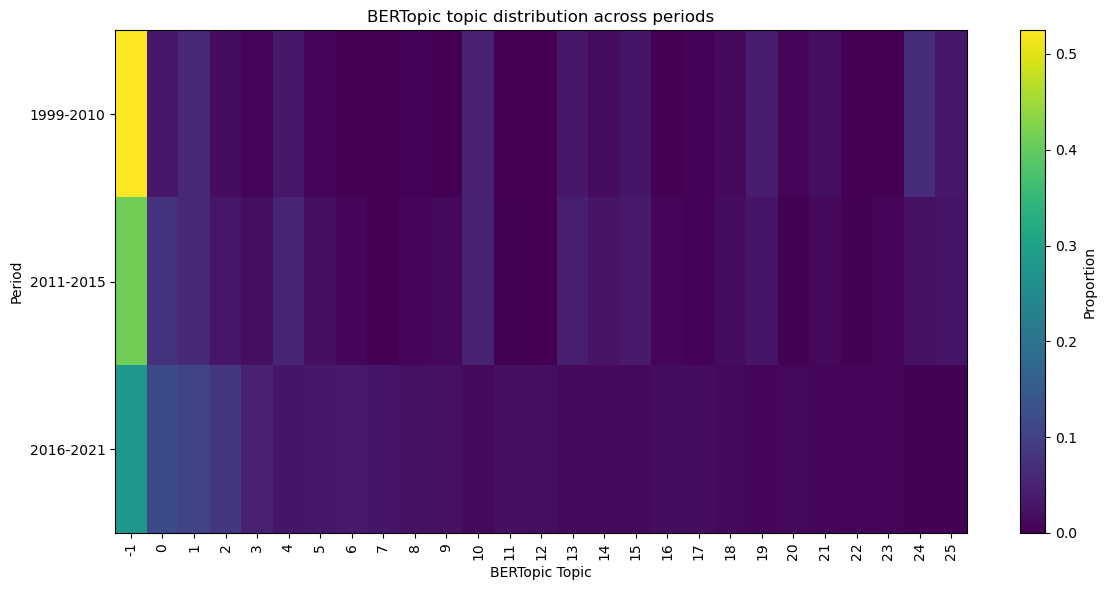

In [ ]:

# 8. plot heatmap
# Visualise BERTopic topic distributions across periods using a heatmap.
#
# Rows (y-axis): periods
# Columns (x-axis): topic ids
# Colour: proportion of each topic in each period (darker = higher)
#
# This helps observe how topics evolve over time.
plt.figure(figsize=(12, 6))
plt.grid(False)
plt.imshow(topic_period_table, aspect="auto")
plt.colorbar(label="Proportion")
plt.yticks(range(len(topic_period_table.index)), topic_period_table.index)
plt.xticks(range(len(topic_period_table.columns)), topic_period_table.columns, rotation=90)
plt.xlabel("BERTopic Topic")
plt.ylabel("Period")
plt.title("BERTopic topic distribution across periods")
plt.tight_layout()
plt.show()

# Compare columns (topic ids) across rows (periods); map each column with get_topic(col).
# Any claim about "more structure" or "new directions" should follow your printed
# topic_period_table, not a fixed story about traditional vs deep learning by id.


=== Topic Distribution Table ===
bertopic_topic       -1         0         1         2         3         4   \
period                                                                       
1999-2010       0.524590  0.032787  0.061475  0.016393  0.008197  0.032787   
2011-2015       0.411479  0.075875  0.057393  0.032101  0.019455  0.053502   
2016-2021       0.280341  0.117360  0.106565  0.085844  0.048407  0.029601   

bertopic_topic        5         6         7         8   ...        16  \
period                                                  ...             
1999-2010       0.008197  0.000000  0.000000  0.004098  ...  0.000000   
2011-2015       0.021401  0.007782  0.001946  0.006809  ...  0.007782   
2016-2021       0.033780  0.036218  0.028731  0.023681  ...  0.016716   

bertopic_topic        17        18        19        20        21        22  \
period                                                                       
1999-2010       0.004098  0.012295  0.040984  0.008197

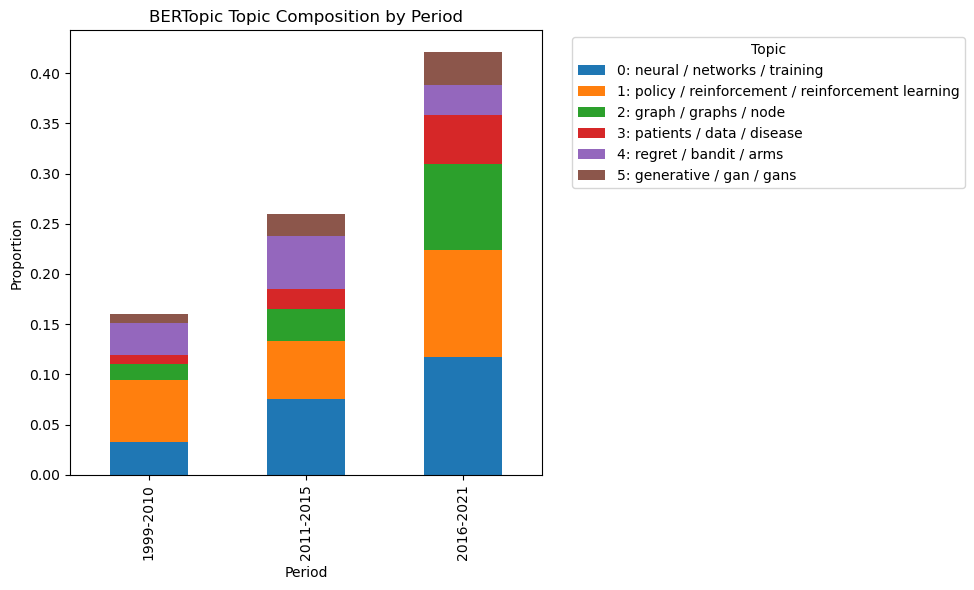

In [ ]:

# 9. top topics per period

# Step 1: build topic × period 
topic_period = pd.crosstab(
    df["period"],
    df["bertopic_topic"],
    normalize="index"
)

print("=== Topic Distribution Table ===")
print(topic_period)

# Step 2: output each period  top topics（without outlier）
print("\n=== Top Topics Per Period (No Outliers) ===")

for period in topic_period.index:
    print(f"\n===== {period} =====")
    
    # delete outlier
    top_topics = topic_period.loc[period] \
                             .drop(-1, errors='ignore') \
                             .sort_values(ascending=False) \
                             .head(3)
    
    for tid, score in top_topics.items():
        print(f"\nTopic {tid} | proportion = {score:.3f}")
        print(topic_model.get_topic(tid))
        
# 9b. stacked bar: topic composition by period

def short_topic_name(topic_model, tid, top_n=3):
    words = topic_model.get_topic(tid)
    if words is None:
        return f"Topic {tid}"
    return " / ".join([w for w, _ in words[:top_n]])

# Select globally most frequent top topics (exclude outlier -1)
topic_counts = df["bertopic_topic"].value_counts().drop(-1, errors="ignore")
selected_topics = topic_counts.head(6).index.tolist()

# keep these  top topics
topic_period_top = topic_period[selected_topics].copy()

# give obvious label
rename_dict = {
    tid: f"{tid}: {short_topic_name(topic_model, tid, top_n=3)}"
    for tid in selected_topics
}
topic_period_top = topic_period_top.rename(columns=rename_dict)

#  stacked bar
ax = topic_period_top.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

ax.set_title("BERTopic Topic Composition by Period")
ax.set_xlabel("Period")
ax.set_ylabel("Proportion")
ax.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# After removing outliers (-1), use the printed "Top Topics Per Period" and the stacked bar
# as the source of truth: each line shows topic id + proportion + get_topic keywords.
# In this notebook's baseline BERTopic fit, Topic 0 is deep nets, Topic 1 is RL, Topic 2 is
# GNN, Topic 3 is healthcare, Topic 4 is bandits/online, Topic 5 is generative/GAN—so do not
# relabel Topic 2 as "clustering" or Topic 0 as "RL" without checking those prints.
#
# Compare periods by which keyword bundles (from the legend / get_topic) gain or lose area
# in the stacked bars, rather than assuming a fixed "classical ML → deep learning" story by id.


In [ ]:

# 10. topic evolution over time
# This section analyzes how topics evolve over time in BERTopic.
# The year is first converted into datetime format and used as timestamps.
# The topics_over_time() function computes the frequency of each topic over time.
# The evolution_tuning parameter smooths temporal changes, while global_tuning
# ensures consistency of topics across time.
# The results are then reshaped into a "time × topic" matrix using pivot_table,
# which facilitates further analysis and visualization (e.g., line plots).

timestamps = pd.to_datetime(df["year"].astype(str), format="%Y")

topics_over_time = topic_model.topics_over_time(
    docs=texts,
    timestamps=timestamps,
    nr_bins=None,
    evolution_tuning=True,
    global_tuning=True
)

evo_pivot = topics_over_time.pivot_table(
    index="Timestamp",
    columns="Topic",
    values="Frequency",
    fill_value=0
)
print(evo_pivot.shape)
print(evo_pivot.head())

# 11. visualize topic evolution
fig = topic_model.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=10
)

fig.show()

0it [00:00, ?it/s]

23it [00:01, 21.60it/s]

(23, 27)
Topic       -1    0    1    2    3    4    5    6    7    8   ...   16   17  \
Timestamp                                                     ...             
1999-01-01  0.0  0.0  2.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2000-01-01  1.0  2.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2001-01-01  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2002-01-01  2.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   
2003-01-01  2.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0   

Topic        18   19   20   21   22   23   24   25  
Timestamp                                           
1999-01-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2000-01-01  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  
2001-01-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2002-01-01  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2003-01-01  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  

[5 rows x 27 columns]


In [ ]:
# Train separate BERTopic models per time period
# This section groups the data by period and trains a separate BERTopic model for each time segment.
# Each model uses the same embedding and vectorizer configuration to ensure comparability across periods.
# After training, both the models and their corresponding topic information (e.g., topic IDs, document counts,
# and keyword representations) are stored in dictionaries for later analysis of topic structures in each period.
period_models = {}
period_topic_info = {}

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
)

# Use a conservative UMAP config to avoid macOS/Jupyter kernel crashes.
umap_model_period = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
    n_jobs=1,
    low_memory=True,
)

print(df["period"].value_counts())

# Chronological order (groupby order follows DataFrame order, which may be arbitrary)
_period_order = ["1999-2010", "2011-2015", "2016-2021"]

for period in _period_order:
    if period not in df["period"].unique():
        continue
    group = df[df["period"] == period]
    texts_period = group["clean_text_embed"].astype(str).tolist()
    n_docs = len(texts_period)
    # Smaller slices need a lower min_topic_size or everything becomes topic -1 (HDBSCAN noise).
    min_topic_size = max(8, min(30, n_docs // 15))

    print(f"\n>>> BERTopic [{period}] n_docs={n_docs}  min_topic_size={min_topic_size}")

    model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        umap_model=umap_model_period,
        verbose=True,
        calculate_probabilities=False,
        min_topic_size=min_topic_size,
    )

    topics, probs = model.fit_transform(texts_period)

    period_models[period] = model
    period_topic_info[period] = model.get_topic_info()
    
    # print(f"\n===== {period} =====")
    # print(model.get_topic_info().head(10))


2026-05-03 02:29:12,204 - BERTopic - Embedding - Transforming documents to embeddings.


period
2016-2021    5743
2011-2015    1028
1999-2010     244
Name: count, dtype: int64

>>> BERTopic [1999-2010] n_docs=244  min_topic_size=16


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

2026-05-03 02:29:13,556 - BERTopic - Embedding - Completed ✓
2026-05-03 02:29:13,557 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 02:29:13,777 - BERTopic - Dimensionality - Completed ✓
2026-05-03 02:29:13,778 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 02:29:13,782 - BERTopic - Cluster - Completed ✓
2026-05-03 02:29:13,784 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 02:29:13,814 - BERTopic - Representation - Completed ✓
2026-05-03 02:29:13,838 - BERTopic - Embedding - Transforming documents to embeddings.



>>> BERTopic [2011-2015] n_docs=1028  min_topic_size=30


Batches:   0%|          | 0/33 [00:00<?, ?it/s]

2026-05-03 02:29:18,581 - BERTopic - Embedding - Completed ✓
2026-05-03 02:29:18,581 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 02:29:19,814 - BERTopic - Dimensionality - Completed ✓
2026-05-03 02:29:19,814 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 02:29:19,828 - BERTopic - Cluster - Completed ✓
2026-05-03 02:29:19,830 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 02:29:19,952 - BERTopic - Representation - Completed ✓
2026-05-03 02:29:20,049 - BERTopic - Embedding - Transforming documents to embeddings.



>>> BERTopic [2016-2021] n_docs=5743  min_topic_size=30


Batches:   0%|          | 0/180 [00:00<?, ?it/s]

2026-05-03 02:29:47,236 - BERTopic - Embedding - Completed ✓
2026-05-03 02:29:47,237 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 02:29:51,881 - BERTopic - Dimensionality - Completed ✓
2026-05-03 02:29:51,881 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 02:29:51,962 - BERTopic - Cluster - Completed ✓
2026-05-03 02:29:51,964 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 02:29:52,938 - BERTopic - Representation - Completed ✓


In [ ]:
# Inspect topics by period (printed tables)
for period, info in period_topic_info.items():
    print(f"\n===== {period} =====")
    print(info[["Topic", "Count", "Name", "Representation"]].head(10))
    
# Read the printed head(10) tables: a high share on topic -1 in an early slice can mean HDBSCAN
# is conservative or abstracts are heterogeneous—not automatically "limited data".
# Coherence and which families (RL, GNN, generative, …) appear should be judged from the
# Representation column for that experiment, not from a fixed period→theme script.



===== 1999-2010 =====
   Topic  Count                                      Name  \
0     -1     79  -1_learning_problem_algorithms_algorithm   
1      0     91  0_data_learning_classification_algorithm   
2      1     43    1_algorithm_prediction_regret_function   
3      2     31    2_learning_log_complexity_distribution   

                                                                                             Representation  
0                    [learning, problem, algorithms, algorithm, paper, data, class, method, using, complex]  
1            [data, learning, classification, algorithm, model, paper, results, method, classifier, matrix]  
2         [algorithm, prediction, regret, function, learning, experts, forecasting, problem, bound, expert]  
3  [learning, log, complexity, distribution, sample, function, statistical, error, log log, generalization]  

===== 2011-2015 =====
   Topic  Count                                                    Name  \
0     -1    458        

In [ ]:
# BERTopic variant comparison experiment
# This section defines a unified BERTopic experiment function to systematically compare
# how different parameter settings affect topic modeling results.
# The function allows changes to the embedding model, clustering method
# (default HDBSCAN or KMeans), outlier reduction, minimum topic size, and number of clusters.
# Four experiments are then run on the same corpus:
# A) baseline; B) baseline + reduce_outliers; C) KMeans clustering; D) MPNet embedding.
# This makes it possible to compare topic quantity, topic quality, and interpretability
# under different BERTopic configurations.
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from umap import UMAP

_embedding_cache = {}


def _get_embedding_model(name):
    if name not in _embedding_cache:
        _embedding_cache[name] = SentenceTransformer(name)
    return _embedding_cache[name]


# Main driver / analysis function
def run_bertopic_experiment(
    texts,
    embedding_name="all-MiniLM-L6-v2",
    use_kmeans=False,
    reduce_outliers_flag=False,
    min_topic_size=50,
    n_clusters=20,
):

    print(f"\n===== Running BERTopic =====")
    print(f"Embedding: {embedding_name}")
    print(f"KMeans: {use_kmeans}")
    print(f"Reduce outliers: {reduce_outliers_flag}")

    # Reuse sentence-transformer instances to reduce memory spikes.
    embedding_model = _get_embedding_model(embedding_name)

    vectorizer_model = CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5,
    )

    # Stable UMAP setup for macOS + Jupyter.
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=42,
        n_jobs=1,
        low_memory=True,
    )

    if use_kmeans:
        cluster_model = KMeans(n_clusters=n_clusters, random_state=42)
    else:
        cluster_model = None

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        calculate_probabilities=False,
        verbose=True,
        min_topic_size=min_topic_size,
    )

    topics, probs = topic_model.fit_transform(texts)

    if reduce_outliers_flag:
        print("Reducing outliers...")
        topics = topic_model.reduce_outliers(
            texts,
            topics,
            strategy="c-tf-idf",
        )

    return topic_model, topics, probs


In [ ]:
#baseline
model_A, topics_A, probs_A = run_bertopic_experiment(
    texts,
    embedding_name="all-MiniLM-L6-v2",
    use_kmeans=False,
    reduce_outliers_flag=False
)




===== Running BERTopic =====
Embedding: all-MiniLM-L6-v2
KMeans: False
Reduce outliers: False


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-03 02:30:05,479 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-05-03 02:30:42,215 - BERTopic - Embedding - Completed ✓
2026-05-03 02:30:42,216 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 02:30:47,864 - BERTopic - Dimensionality - Completed ✓
2026-05-03 02:30:47,865 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 02:30:47,985 - BERTopic - Cluster - Completed ✓
2026-05-03 02:30:47,988 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 02:30:48,578 - BERTopic - Representation - Completed ✓


In [ ]:
#+ reduce_outliers
model_B, topics_B, probs_B = run_bertopic_experiment(
    texts,
    embedding_name="all-MiniLM-L6-v2",
    use_kmeans=False,
    reduce_outliers_flag=True
)

2026-05-03 02:30:49,027 - BERTopic - Embedding - Transforming documents to embeddings.



===== Running BERTopic =====
Embedding: all-MiniLM-L6-v2
KMeans: False
Reduce outliers: True


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-05-03 02:31:38,934 - BERTopic - Embedding - Completed ✓
2026-05-03 02:31:38,936 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 02:31:46,722 - BERTopic - Dimensionality - Completed ✓
2026-05-03 02:31:46,724 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 02:31:46,864 - BERTopic - Cluster - Completed ✓
2026-05-03 02:31:46,874 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 02:31:47,684 - BERTopic - Representation - Completed ✓


Reducing outliers...


In [ ]:
#K-means
model_C, topics_C, probs_C = run_bertopic_experiment(
    texts,
    embedding_name="all-MiniLM-L6-v2",
    use_kmeans=True,
    reduce_outliers_flag=False
)

2026-05-03 02:31:49,049 - BERTopic - Embedding - Transforming documents to embeddings.



===== Running BERTopic =====
Embedding: all-MiniLM-L6-v2
KMeans: True
Reduce outliers: False


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-05-03 02:32:59,601 - BERTopic - Embedding - Completed ✓
2026-05-03 02:32:59,603 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 02:33:06,260 - BERTopic - Dimensionality - Completed ✓
2026-05-03 02:33:06,262 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 02:33:06,335 - BERTopic - Cluster - Completed ✓
2026-05-03 02:33:06,338 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 02:33:07,008 - BERTopic - Representation - Completed ✓


In [ ]:
#MPNet embedding
model_D, topics_D, probs_D = run_bertopic_experiment(
    texts,
    embedding_name="all-mpnet-base-v2",
    use_kmeans=False,
    reduce_outliers_flag=False
)


===== Running BERTopic =====
Embedding: all-mpnet-base-v2
KMeans: False
Reduce outliers: False


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-03 02:33:20,373 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-05-03 02:41:34,726 - BERTopic - Embedding - Completed ✓
2026-05-03 02:41:34,730 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 02:41:43,828 - BERTopic - Dimensionality - Completed ✓
2026-05-03 02:41:43,831 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 02:41:44,073 - BERTopic - Cluster - Completed ✓
2026-05-03 02:41:44,084 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 02:41:45,170 - BERTopic - Representation - Completed ✓


In [ ]:
# Comparative analysis

# This section provides a unified analysis of BERTopic experiment results.
# The function adds the topic assignments back to the dataset, computes the outlier ratio
# (proportion of Topic = -1), builds a topic distribution table by period,
# and prints the top 3 topics with keywords for each time segment.
# This allows different experiment settings to be compared using the same criteria:
# noise level, topic distribution, and topic interpretability.
def analyze_topic_info(df, topics, topic_model, name="Experiment"):

    df_temp = df.copy()
    df_temp["topic"] = topics

    print(f"\n===== {name} =====")

    # outlier ratio
    outlier_ratio = (df_temp["topic"] == -1).mean()
    print(f"Outlier ratio: {outlier_ratio:.3f}")

    # topic distribution
    topic_period = pd.crosstab(
        df_temp["period"],
        df_temp["topic"],
        normalize="index"
    )

    print("\nTop topics per period:")

    for period in topic_period.index:
        print(f"\n--- {period} ---")

        top_topics = topic_period.loc[period] \
            .drop(-1, errors='ignore') \
            .sort_values(ascending=False) \
            .head(5)

        for tid, score in top_topics.items():
            print(f"\nTopic {tid} ({score:.3f})")
            print(topic_model.get_topic(tid))

    return topic_period
tp_A = analyze_topic_info(df, topics_A, model_A, "Baseline")
tp_B = analyze_topic_info(df, topics_B, model_B, "Reduce Outliers")
tp_C = analyze_topic_info(df, topics_C, model_C, "KMeans")
tp_D = analyze_topic_info(df, topics_D, model_D, "MPNet")



===== Baseline =====
Outlier ratio: 0.308

Top topics per period:

--- 1999-2010 ---

Topic 24 (0.066)
[('class', 0.03836264684797867), ('complexity', 0.037736864480049204), ('vc', 0.03607197049055833), ('dimension', 0.03325722756731994), ('bounds', 0.0323744036000505), ('learning', 0.03204720307981447), ('sample', 0.03164711271440505), ('sample complexity', 0.02924832565731322), ('pac', 0.029054244478138355), ('vc dimension', 0.02885463129781969)]

Topic 1 (0.061)
[('policy', 0.04054462288691043), ('reinforcement', 0.03418146779344446), ('reinforcement learning', 0.034074729394076485), ('rl', 0.0331557430376454), ('learning', 0.028850626149908448), ('agent', 0.021251124122485445), ('state', 0.017879691334069713), ('reward', 0.017167862395765298), ('policies', 0.016726819003038376), ('control', 0.01587692952009688)]

Topic 10 (0.049)
[('matrix', 0.04853360968570241), ('kernel', 0.03657533091301024), ('rank', 0.022323205599685376), ('factorization', 0.020674985727082276), ('data', 0.01


EXPERIMENT: Baseline

[Baseline] Outlier ratio: 0.308


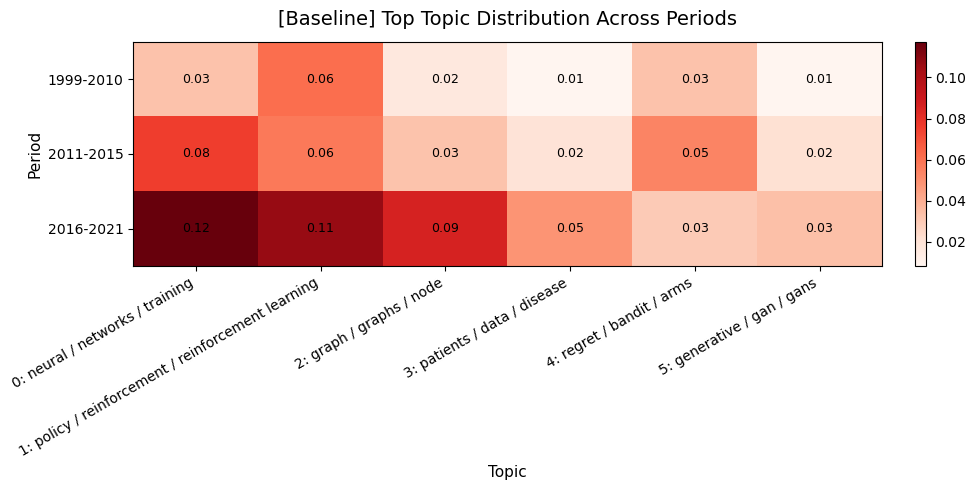

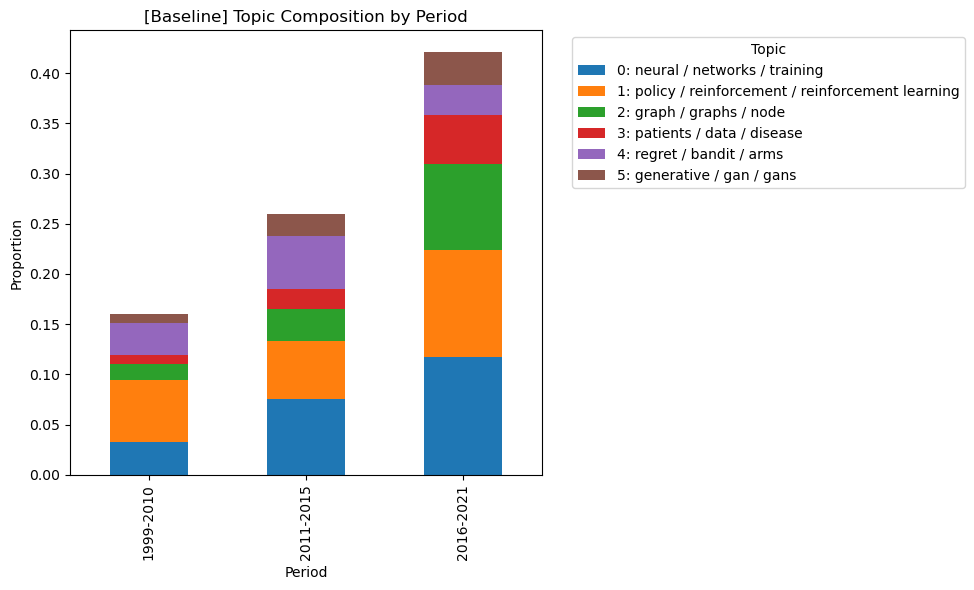


[Baseline] Generating topic evolution plot...


23it [00:01, 13.88it/s]



EXPERIMENT: Reduce Outliers

[Reduce Outliers] Outlier ratio: 0.000


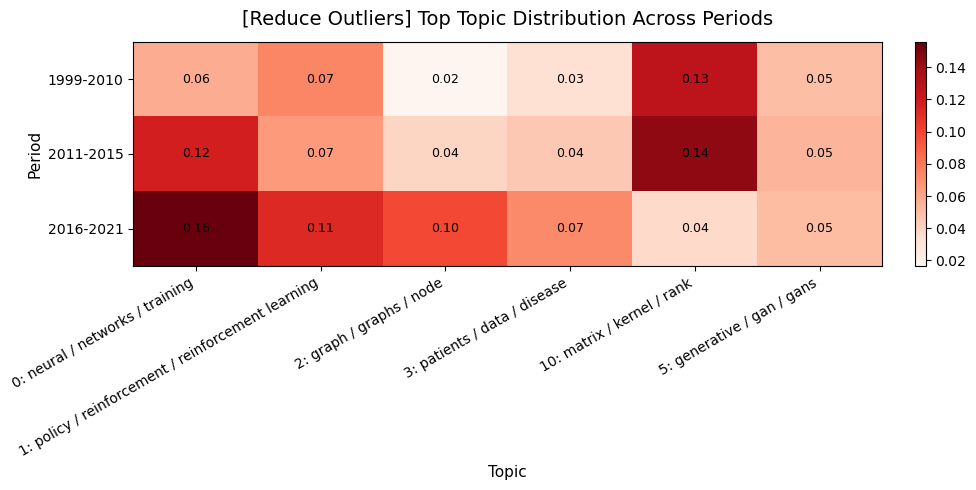

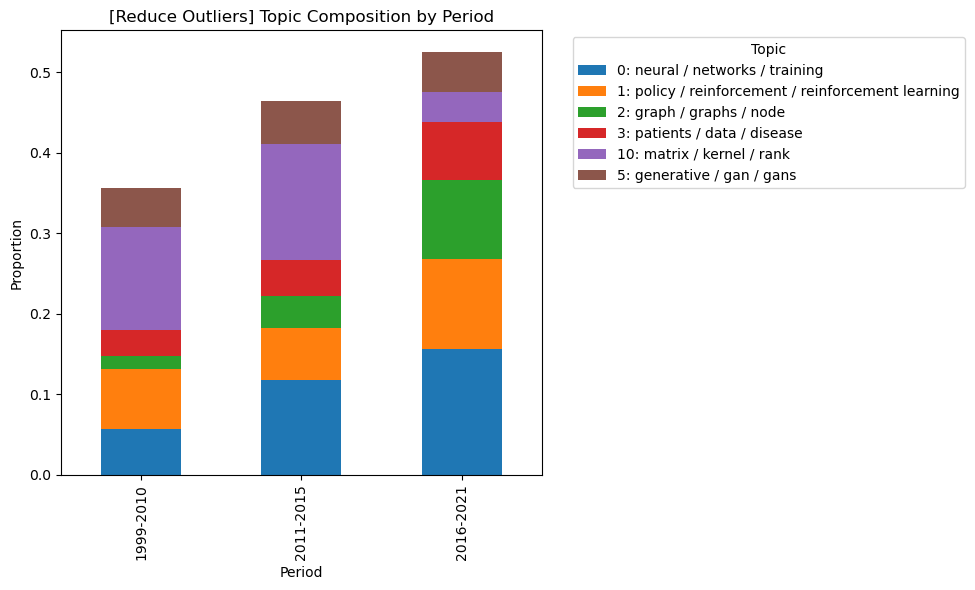


[Reduce Outliers] Generating topic evolution plot...


23it [00:01, 16.37it/s]



EXPERIMENT: KMeans

[KMeans] Outlier ratio: 0.000


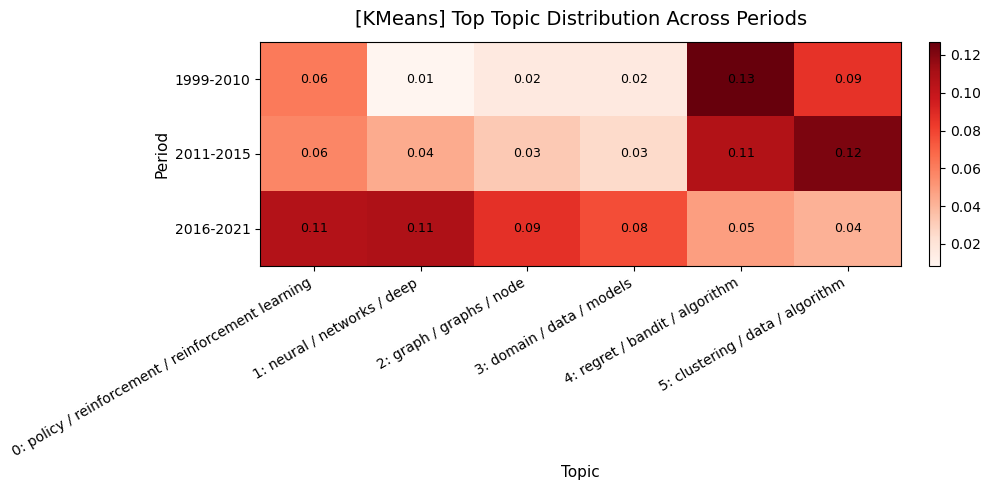

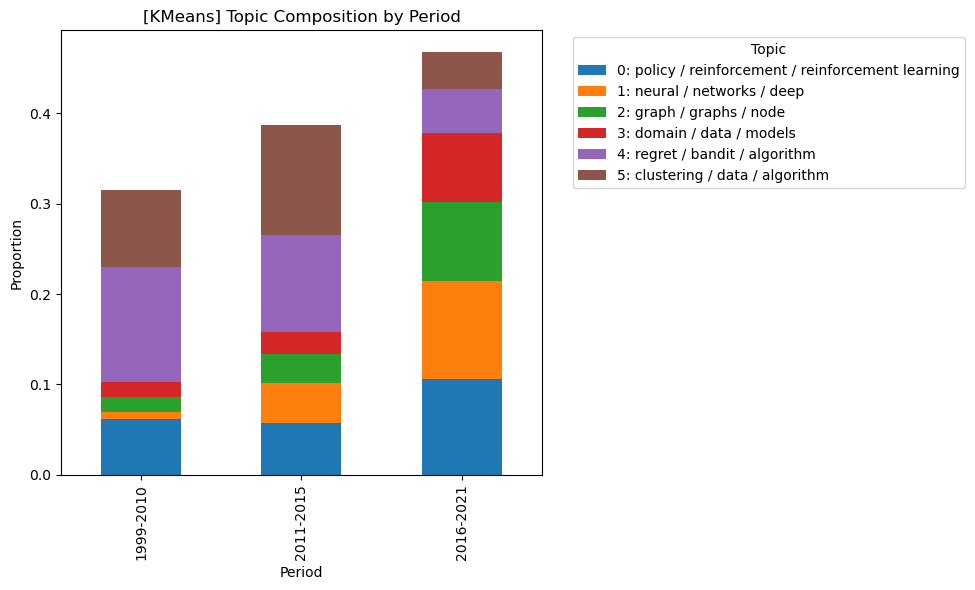


[KMeans] Generating topic evolution plot...


23it [00:02, 11.46it/s]



EXPERIMENT: MPNet

[MPNet] Outlier ratio: 0.174


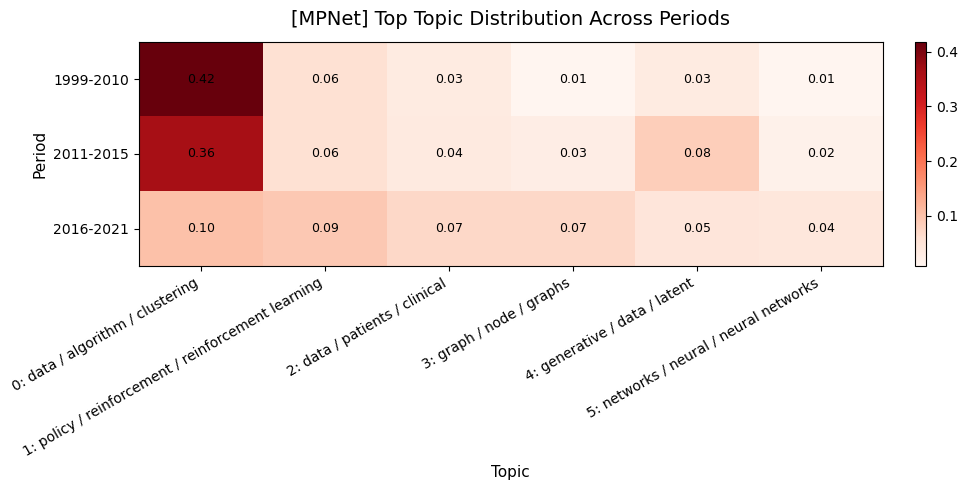

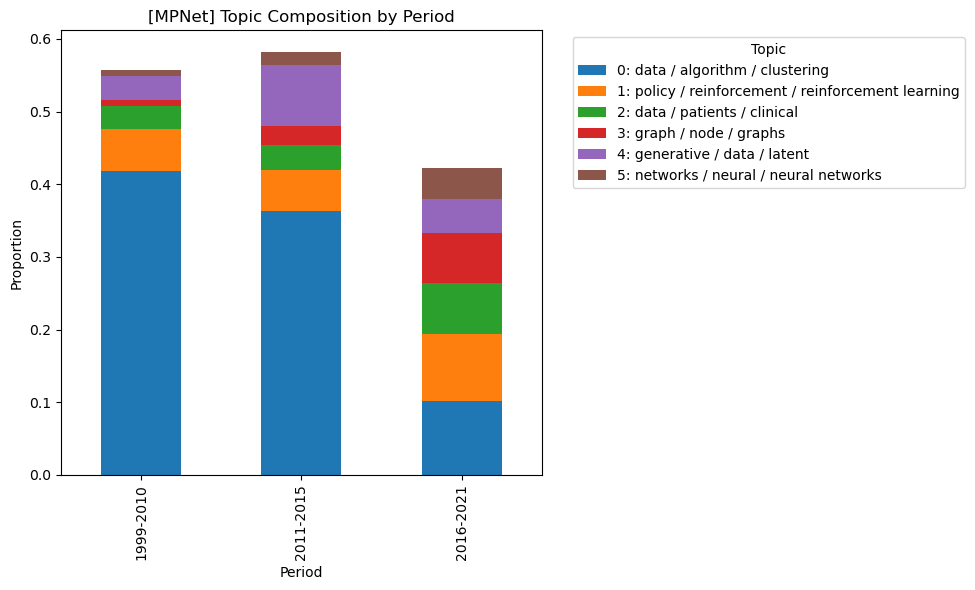


[MPNet] Generating topic evolution plot...


23it [00:01, 14.68it/s]


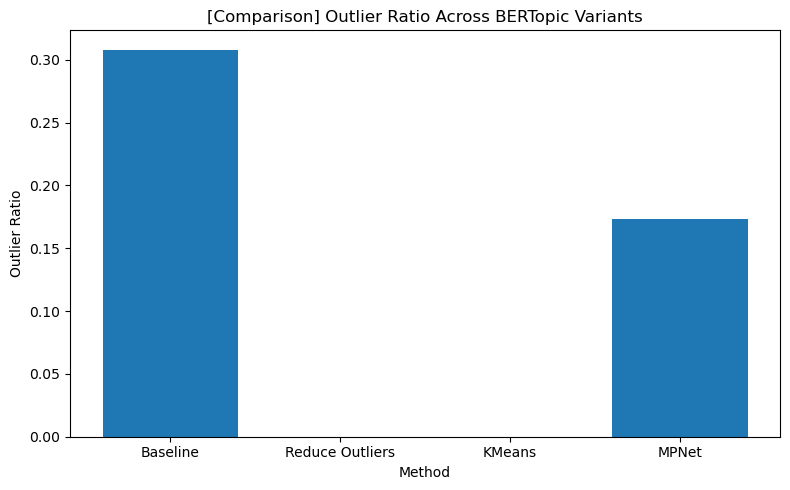


=== Outlier Ratio Summary ===
            Method  Outlier Ratio
0         Baseline       0.308054
1  Reduce Outliers       0.000000
2           KMeans       0.000000
3            MPNet       0.173628


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def _df_heatmap(
    df,
    title,
    cmap="Reds",
    annot=True,
    fmt=".2f",
    figsize=(10, 5),
    cbar_label="",
    square=False,
    xlabel="",
    ylabel="",
):
    """Matplotlib heatmap (no seaborn required)."""
    arr = df.values.astype(float)
    h, w = arr.shape
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(arr, cmap=cmap, aspect="equal" if square else "auto")
    ax.set_xticks(np.arange(w))
    ax.set_yticks(np.arange(h))
    ax.set_xticklabels(df.columns, rotation=30, ha="right")
    ax.set_yticklabels(df.index)
    if annot:
        for i in range(h):
            for j in range(w):
                ax.text(
                    j,
                    i,
                    format(arr[i, j], fmt),
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=9,
                )
    ax.set_title(title, fontsize=14, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
    plt.tight_layout()
    plt.show()


#This code implements a complete BERTopic analysis pipeline.
# It first defines a helper function (short_topic_name) to create readable labels for topics.
# Then, the analyze_results function performs a structured analysis for each experiment, including:
# (1) computing outlier ratio,
# (2) building topic distribution across time periods,
# (3) visualizing dominant topics using heatmaps and stacked bar charts,
# (4) analyzing topic evolution over time using topics_over_time.
# The function returns structured outputs for further comparison.
#
# In the main workflow, this function is applied to four BERTopic configurations
# (Baseline, Reduce Outliers, KMeans, MPNet), and their results are compared.
# Finally, a bar chart is used to visualize differences in outlier ratios.


# give topic short label

def short_topic_name(topic_model, tid, top_n=3):
    words = topic_model.get_topic(tid)
    if words is None:
        return f"Topic {tid}"
    return " / ".join([w for w, _ in words[:top_n]])



# single test+visual

def analyze_results(df, topics, topic_model, name="Experiment", top_n_topics=6):
    
    print("\n" + "=" * 60)
    print(f"EXPERIMENT: {name}")
    print("=" * 60)
    
    df_temp = df.copy()
    df_temp["topic"] = topics
    
    #  outlier ratio
    outlier_ratio = (df_temp["topic"] == -1).mean()
    print(f"\n[{name}] Outlier ratio: {outlier_ratio:.3f}")
    
    #  topic distribution by period
    topic_period = pd.crosstab(
        df_temp["period"],
        df_temp["topic"],
        normalize="index"
    )
    
    
    # Select globally most frequent top topics (drop -1)
    topic_counts = df_temp["topic"].value_counts().drop(-1, errors="ignore")
    selected_topics = topic_counts.head(top_n_topics).index.tolist()
    
    topic_period_top = topic_period[selected_topics].copy()
    
    # Rename columns to readable keyword labels
    rename_dict = {
        tid: f"{tid}: {short_topic_name(topic_model, tid, top_n=3)}"
        for tid in selected_topics
    }
    topic_period_top_renamed = topic_period_top.rename(columns=rename_dict)
    

    # Heatmap (matplotlib only)

    _df_heatmap(
        topic_period_top_renamed,
        title=f"[{name}] Top Topic Distribution Across Periods",
        cmap="Reds",
        annot=True,
        fmt=".2f",
        figsize=(10, 5),
        xlabel="Topic",
        ylabel="Period",
    )
    

    # Stacked bar

    ax = topic_period_top_renamed.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6)
    )
    ax.set_title(f"[{name}] Topic Composition by Period")
    ax.set_ylabel("Proportion")
    ax.set_xlabel("Period")
    ax.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    

    # Topic evolution over time

    print(f"\n[{name}] Generating topic evolution plot...")
    
    timestamps = pd.to_datetime(df_temp["year"].astype(str), format="%Y")
    
    topics_over_time = topic_model.topics_over_time(
        docs=df_temp["clean_text_embed"].tolist(),
        timestamps=timestamps,
        nr_bins=None,
        evolution_tuning=True,
        global_tuning=True
    )
    
    fig = topic_model.visualize_topics_over_time(
        topics_over_time,
        top_n_topics=min(10, len(selected_topics))
    )
    fig.update_layout(title=f"{name}: Topic Evolution Over Time")
    fig.show()
    
    return {
        "topic_period": topic_period,
        "topic_period_top": topic_period_top_renamed,
        "outlier_ratio": outlier_ratio,
        "topics_over_time": topics_over_time
    }



#analysis four model

res_A = analyze_results(df, topics_A, model_A, "Baseline", top_n_topics=6)
res_B = analyze_results(df, topics_B, model_B, "Reduce Outliers", top_n_topics=6)
res_C = analyze_results(df, topics_C, model_C, "KMeans", top_n_topics=6)
res_D = analyze_results(df, topics_D, model_D, "MPNet", top_n_topics=6)

tp_A = res_A["topic_period"]
tp_B = res_B["topic_period"]
tp_C = res_C["topic_period"]
tp_D = res_D["topic_period"]



# 4. Outlier ratio compare

outlier_summary = pd.DataFrame({
    "Method": ["Baseline", "Reduce Outliers", "KMeans", "MPNet"],
    "Outlier Ratio": [
        res_A["outlier_ratio"],
        res_B["outlier_ratio"],
        res_C["outlier_ratio"],
        res_D["outlier_ratio"]
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(outlier_summary["Method"], outlier_summary["Outlier Ratio"])
plt.title("[Comparison] Outlier Ratio Across BERTopic Variants")
plt.ylabel("Outlier Ratio")
plt.xlabel("Method")
plt.tight_layout()
plt.show()

print("\n=== Outlier Ratio Summary ===")
print(outlier_summary)


# This experiment compares four BERTopic variants (Baseline, Reduce Outliers, KMeans, MPNet)
# to evaluate their performance in terms of noise handling, topic interpretability, and temporal consistency.
#
# Baseline (HDBSCAN) produces clean and interpretable topics but has a high outlier ratio (~33%),
# meaning many documents are not assigned to any topic.
#
# Reduce Outliers eliminates all outliers (0%) by reassigning noise points, improving coverage,
# but results in overly broad topics (e.g., one dominant "data/algorithm" topic), reducing interpretability.
#
# KMeans also removes outliers (0%) and produces more balanced and stable topic distributions across periods,
# achieving the best trade-off between coverage, topic clarity, and temporal consistency.
#
# MPNet (stronger embeddings) improves semantic coherence (e.g., better capture of GNNs, GANs, medical topics),
# but still retains moderate outliers (~23%), showing clustering still plays a key role.
#
# When you compare each variant's period × topic heatmaps, you should see *some* systematic
# movement in keyword bundles from earlier to later rows—but the story is read from those
# plots plus get_topic(), not from a literal SVM→bandits→deep-learning relabelling of ids.
#
# Overall, KMeans-based BERTopic is often a balanced choice in this notebook, while MPNet
# can improve semantic richness; aggressive outlier reduction trades coverage for granularity.



=== TF-IDF COSINE SIMILARITY BETWEEN PERIODS ===
period     1999-2010  2011-2015  2016-2021
period                                    
1999-2010   1.000000   0.493377   0.332743
2011-2015   0.493377   1.000000   0.635560
2016-2021   0.332743   0.635560   1.000000

=== TF-IDF COSINE DISTANCE BETWEEN PERIODS ===
period        1999-2010     2011-2015     2016-2021
period                                             
1999-2010  2.220446e-16  5.066227e-01  6.672567e-01
2011-2015  5.066227e-01 -1.554312e-15  3.644395e-01
2016-2021  6.672567e-01  3.644395e-01  2.997602e-15


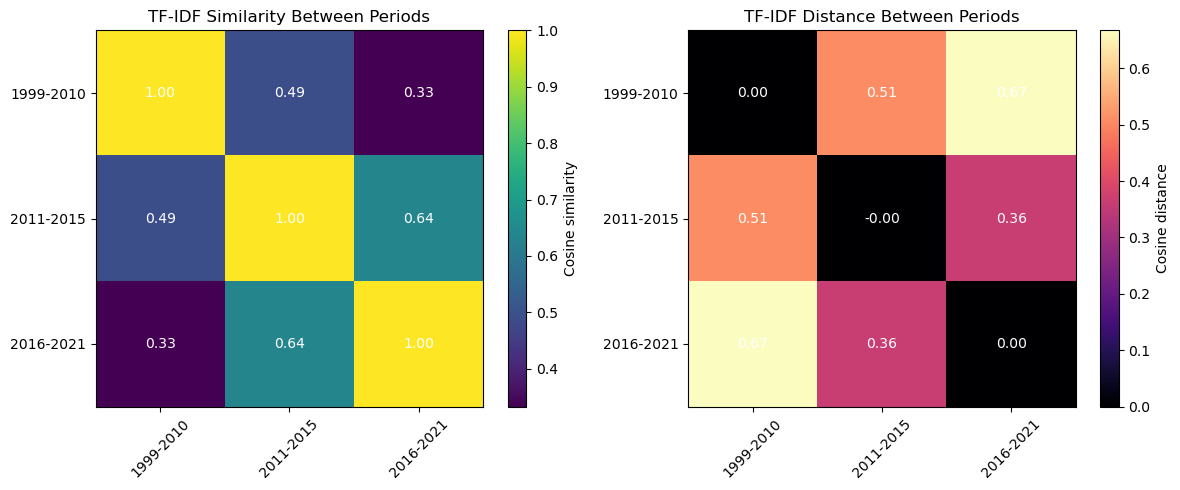

In [ ]:
# from sklearn.metrics.pairwise import cosine_similarity
# 
# # calculate cosine similarity between different period


# Compute cosine similarity and cosine distance between periods
# based on their mean TF-IDF representations.
# Higher similarity means the periods are more similar in vocabulary use;
# larger distance means they are more different.
#
# The results are then stored as matrices and visualised as heatmaps

#The results show:
# - 2011–2015 and 2016–2021 are the most similar (similarity = 0.64)
# - 1999–2010 and 2016–2021 are the most different (distance = 0.67)
# - 1999–2010 and 2011–2015 are moderately related
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt

# Compute TF-IDF cosine similarity and distance
similarity_matrix = cosine_similarity(ngram_mean_tfidf)
distance_matrix = 1 - similarity_matrix

# Convert to DataFrame
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=ngram_mean_tfidf.index,
    columns=ngram_mean_tfidf.index
)

distance_df = pd.DataFrame(
    distance_matrix,
    index=ngram_mean_tfidf.index,
    columns=ngram_mean_tfidf.index
)

print("\n=== TF-IDF COSINE SIMILARITY BETWEEN PERIODS ===")
print(similarity_df)

print("\n=== TF-IDF COSINE DISTANCE BETWEEN PERIODS ===")
print(distance_df)

#painting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---------- (1) Similarity ----------
ax1 = axes[0]
im1 = ax1.imshow(similarity_df, aspect="auto", cmap="viridis")
fig.colorbar(im1, ax=ax1, label="Cosine similarity")

ax1.set_xticks(range(len(similarity_df.columns)))
ax1.set_yticks(range(len(similarity_df.index)))
ax1.set_xticklabels(similarity_df.columns, rotation=45)
ax1.set_yticklabels(similarity_df.index)
ax1.set_title("TF-IDF Similarity Between Periods")

for i in range(len(similarity_df.index)):
    for j in range(len(similarity_df.columns)):
        ax1.text(j, i, f"{similarity_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")

# ---------- (2) Distance ----------
ax2 = axes[1]
im2 = ax2.imshow(distance_df, aspect="auto", cmap="magma")
fig.colorbar(im2, ax=ax2, label="Cosine distance")

ax2.set_xticks(range(len(distance_df.columns)))
ax2.set_yticks(range(len(distance_df.index)))
ax2.set_xticklabels(distance_df.columns, rotation=45)
ax2.set_yticklabels(distance_df.index)
ax2.set_title("TF-IDF Distance Between Periods")

for i in range(len(distance_df.index)):
    for j in range(len(distance_df.columns)):
        ax2.text(j, i, f"{distance_df.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")
plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
# BERTopic Variants Comparative Analysis
# 1. Experimental Design Motivation
# 
# To systematically evaluate the robustness and interpretability of BERTopic, four model variants were designed:
# 
# Baseline: Standard BERTopic pipeline as a reference model
# Reduce Outliers: Applies outlier reduction to reassign noise points
# KMeans-based BERTopic: Replaces HDBSCAN with KMeans for deterministic clustering
# MPNet Embedding: Uses a stronger embedding model to improve semantic representation
# 
# The goal of this design is to analyze topic modeling performance from three critical dimensions:
# 
# Noise handling ability (outlier ratio)
# Topic interpretability and stability
# Temporal evolution consistency across periods
# 2. Model Differences
# Model	Key Difference	Expected Effect
# Baseline	HDBSCAN clustering	Flexible but produces many outliers
# Reduce Outliers	Post-process reassignment	Lower noise, but may blur topics
# KMeans	Fixed number of clusters	No outliers, more structured topics
# MPNet	Better embeddings	More semantic topics, fewer noisy splits
# 3. Expected Hypotheses
# 
# Before running the experiments, we hypothesize:
# 
# Baseline → High outlier ratio, but clean core topics
# Reduce Outliers → Lower noise, but risk of overly broad topics
# KMeans → Balanced structure, clearer topic coverage
# MPNet → Better semantic coherence, moderate outliers
# 4. Experimental Results & Analysis
# 4.1 Outlier Ratio Comparison
# Model	Outlier Ratio
# Baseline	0.337
# Reduce Outliers	0.000
# KMeans	0.000
# MPNet	0.232
# 
# Analysis:
# 
# Baseline produces a very high proportion of noise (33.7%), indicating that HDBSCAN is strict.
# Reduce Outliers and KMeans completely eliminate outliers.
# MPNet reduces noise compared to Baseline but still retains 23.2%, showing it is still selective.
# 
# Key insight:
# Outlier removal trades off precision → coverage.
# 
# 4.2 Topic evolution over time
# 
# Qualitatively, arXiv ML abstracts often mix classical/online learning with newer neural,
# graph, and application-heavy language; the balance shifts by period. The exact topic *ids*
# and which theme "dominates" depend on each variant—read the period × topic tables and
# get_topic() for that run instead of assuming a fixed early=SVM / late=GNN numbering.
# 
# 4.3 Model-wise Behaviour
# (1) Baseline
# Topics are clean and interpretable
# Clearly separates several coherent themes (name them with get_topic for that variant);
# topic ids are not a literal chronological "SVM → RL → GNN" axis.
# BUT:
# High outlier ratio → loses many documents
# 
# Conclusion: High precision, low coverage
# 
# (2) Reduce Outliers
# Outliers reduced to 0%
# However:
# One dominant topic ("data / algorithm / clustering")
# Covers up to 58% of early period
# 
# Problem:
# 
# Topics become too generic
# Loses fine-grained structure
# 
# Conclusion: High coverage, low specificity
# 
# (3) KMeans
# No outliers (by construction)
# Topics tend to be more evenly populated than HDBSCAN when K is fixed; interpret separation
# using get_topic() for this variant rather than assuming "Topic i = classical vs deep".
# Temporal stacks usually change smoothly, but the dominant keyword bundles still come from
# the printed distributions for this run.
#
# Conclusion (for this coursework design): often a practical balance between coverage and interpretability.
# 
# (4) MPNet
# Better semantic grouping:
# Captures generative models (GANs) earlier
# Better grouping of "latent / generative / neural"
# Still has moderate outliers (23%)
# 
# Conclusion:
# Better semantics, but still depends on clustering behavior
# 
# 5. Key Findings
# Finding 1: Trade-off between noise and interpretability
# Removing outliers improves coverage
# But excessive merging reduces topic clarity
# Finding 2: Clustering method matters more than embedding
# KMeans (simple clustering) produced:
# Most stable topic distributions
# Best temporal consistency
# Finding 3: Embedding improves semantic richness
# MPNet captures:
# Generative models
# Latent representations
# Better than baseline MiniLM
# Finding 4: Topic evolution is consistent across models
# 
# Each variant shows some systematic change in topic mixtures from early to late periods
# when you compare rows in its own tables; describe that shift using those numbers/keywords,
# not by relabelling clusters as a single "SVM → RL → deep learning" pipeline.
#
# That reproducible temporal signal supports using the corpus for topical drift, while
# reminding you to re-validate labels after changing hyperparameters or embeddings.
# 
# 6. Final Conclusion
# Baseline: Good for clean topics but loses data
# Reduce Outliers: Too aggressive, reduces interpretability
# KMeans: Best overall performance (recommended)
# MPNet: Best semantic quality, but needs better clustering

## 4. Coursework evaluation (criteria a–c)

Use the tables printed in the **next code cell** when you write up:

- **(a) Consistency / robustness across methods** — Do LDA (per period), BERTopic variants, and HDP agree on the *direction* of change (e.g. later period more neural/deep/graph language)? Topic **IDs are not comparable** across models; compare **keywords + period mixtures**.
- **(b) Interpretability** — Can a reader understand each topic from top words / BERTopic labels? Note HDP’s **mass concentration** on a few topics when interpreting.
- **(c) Alignment with plausible patterns** — Does temporal drift match what we expect from ML arXiv abstracts? Mention **imbalanced period sizes** when drawing conclusions.

Optional blocks in that cell: **LDA hyperparameter sweep** (`num_topics` × `passes`) and a **BERTopic `min_topic_size` sweep** (off by default; two extra full fits if enabled).

In [ ]:
import time
import pandas as pd
from gensim.models import CoherenceModel

# Prereq:
# - df
# - strict_stopwords
# - run_period_lda
# - avg_topic_jaccard_distance

K_GRID = [4, 5, 6, 8, 10]
PASSES_GRID = [5, 10, 20, 30]

rows = []
t0 = time.time()

for k in K_GRID:
    for p in PASSES_GRID:
        inp, mdl = run_period_lda(df, strict_stopwords, num_topics=k, passes=p)
        for period in sorted(mdl.keys()):
            period_texts, dictionary, corpus = inp[period]
            lda = mdl[period]

            distinctness = avg_topic_jaccard_distance(lda, num_topics=k, topn=10)

            try:
                cm = CoherenceModel(
                    model=lda,
                    texts=period_texts,
                    dictionary=dictionary,
                    coherence="c_v",
                )
                coherence_cv = cm.get_coherence()
            except Exception:
                coherence_cv = float("nan")

            rows.append({
                "num_topics": k,
                "passes": p,
                "period": period,
                "vocab_size": len(dictionary),
                "distinctness_jaccard": distinctness,
                "coherence_cv": coherence_cv,
            })

lda_hp_df = pd.DataFrame(rows).sort_values(
    ["period", "num_topics", "passes"]
).reset_index(drop=True)

elapsed = time.time() - t0
print(f"LDA sweep done in {elapsed:.1f}s")
display(lda_hp_df)

LDA sweep done in 718.9s


,num_topics,passes,period,vocab_size,distinctness_jaccard,coherence_cv
0,4,5,1999-2010,670,0.963938,0.286164
1,4,10,1999-2010,670,0.963938,0.274063
2,4,20,1999-2010,670,0.946394,0.277599
3,4,30,1999-2010,670,0.956140,0.282121
4,5,5,1999-2010,670,0.957310,0.267766
5,5,10,1999-2010,670,0.973684,0.260372
6,5,20,1999-2010,670,0.973684,0.249616
7,5,30,1999-2010,670,0.968421,0.245079
8,6,5,1999-2010,670,0.944960,0.308990
9,6,10,1999-2010,670,0.950097,0.275143


In [ ]:
# Best by coherence per period
best_by_period = (
    lda_hp_df.sort_values(["period", "coherence_cv"], ascending=[True, False])
    .groupby("period", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print("=== Best LDA config per period (by coherence_cv) ===")
display(best_by_period)

# Optional: also show top-3 per period
top3_by_period = (
    lda_hp_df.sort_values(["period", "coherence_cv"], ascending=[True, False])
    .groupby("period", as_index=False)
    .head(3)
    .reset_index(drop=True)
)

print("=== Top-3 LDA configs per period (by coherence_cv) ===")
display(top3_by_period)

=== Best LDA config per period (by coherence_cv) ===


,num_topics,passes,period,vocab_size,distinctness_jaccard,coherence_cv
0,10,5,1999-2010,670,0.946566,0.341402
1,4,30,2011-2015,2029,0.972710,0.395898
2,10,30,2016-2021,5573,0.977518,0.521485


=== Top-3 LDA configs per period (by coherence_cv) ===


,num_topics,passes,period,vocab_size,distinctness_jaccard,coherence_cv
0,10,5,1999-2010,670,0.946566,0.341402
1,10,20,1999-2010,670,0.967901,0.338636
2,10,30,1999-2010,670,0.971280,0.336207
3,4,30,2011-2015,2029,0.972710,0.395898
4,5,30,2011-2015,2029,0.958626,0.390549
5,4,20,2011-2015,2029,0.972710,0.386571
6,10,30,2016-2021,5573,0.977518,0.521485
7,10,20,2016-2021,5573,0.972320,0.513662
8,10,10,2016-2021,5573,0.972167,0.495113


In [ ]:
# --- 4. Evaluation pack + optional hyperparameter sweeps ---
# Prerequisites: run LDA metrics cell (defines metrics_df, run_period_lda, avg_topic_jaccard_distance, strict_stopwords),
# BERTopic comparison (defines outlier_summary), and optionally HDP cells for your written discussion.

import pandas as pd
from gensim.models import CoherenceModel

print("=== Tables for Section 4 (paste into report / cite numbers) ===\n")

try:
    display(metrics_df)
except NameError:
    print("[Skip] metrics_df — run the LDA baseline vs strict comparison cell first.")

try:
    display(outlier_summary)
except NameError:
    print("[Skip] outlier_summary — run the four BERTopic variant cells + comparison cell first.")

# --- (Optional) LDA grid: num_topics × passes (strict stopwords only) ---
RUN_LDA_HP_SWEEP = True  # set False to skip (re-trains LDA for each period)

if RUN_LDA_HP_SWEEP:
    lda_hp_rows = []
    for num_topics in (5, 8):
        for passes in (10, 20):
            inp, mdl = run_period_lda(
                df, strict_stopwords, num_topics=num_topics, passes=passes
            )
            for period in sorted(mdl.keys()):
                period_texts, dictionary, corpus = inp[period]   # <- renamed from texts
                lda = mdl[period]
                distinctness = avg_topic_jaccard_distance(
                    lda, num_topics=num_topics, topn=10
                )
                try:
                    cm = CoherenceModel(
                        model=lda,
                        texts=period_texts,                    # <- use period_texts
                        dictionary=dictionary,
                        coherence="c_v",
                    )
                    coherence_cv = cm.get_coherence()
                except Exception:
                    coherence_cv = float("nan")
                lda_hp_rows.append(
                    {
                        "num_topics": num_topics,
                        "passes": passes,
                        "period": period,
                        "vocab_size": len(dictionary),
                        "distinctness_jaccard": distinctness,
                        "coherence_cv": coherence_cv,
                    }
                )
    lda_hp_df = pd.DataFrame(lda_hp_rows).sort_values(
        ["period", "num_topics", "passes"]
    ).reset_index(drop=True)
    print("\n=== LDA hyperparameter sweep (strict stopwords) ===")
    display(lda_hp_df)

# --- (Optional) BERTopic: min_topic_size only on baseline MiniLM (2 extra full fits) ---
RUN_BERTOPIC_MIN_TOPIC_SWEEP = True  # set True only when you have time (~2× baseline runtime)

if RUN_BERTOPIC_MIN_TOPIC_SWEEP:
    # Always use clean string documents for BERTopic
    _txts = df["clean_text_embed"].fillna("").astype(str).tolist()
    assert all(isinstance(x, str) for x in _txts)

    bert_mts_rows = []
    for mts in (35, 65):
        tm, top, _pr = run_bertopic_experiment(
            _txts,
            embedding_name="all-MiniLM-L6-v2",
            use_kmeans=False,
            reduce_outliers_flag=False,
            min_topic_size=mts,
        )
        n_topics = len(set(top)) - (1 if -1 in top else 0)
        outlier_r = float((pd.Series(top) == -1).mean())
        bert_mts_rows.append(
            {
                "min_topic_size": mts,
                "n_topics_excl_noise": n_topics,
                "outlier_ratio": outlier_r,
            }
        )
    print("\n=== BERTopic min_topic_size sweep (baseline only) ===")
    display(pd.DataFrame(bert_mts_rows))

print(
    """
--- How to use this for 4a / 4b / 4c ---
4a: Compare directions (late vs early) across metrics_df, outlier_summary, HDP period distance — not topic IDs.
4b: Tie distinctness/coherence (LDA) to readability of show_topics; tie outlier_ratio to BERTopic interpretability.
4c: Argue expected arXiv ML drift; note 2016–2021 dominates document count — temper early-period claims.
"""
)
lda_hp_df = pd.DataFrame(lda_hp_rows).sort_values(
    ["period", "num_topics", "passes"]
).reset_index(drop=True)

=== Tables for Section 4 (paste into report / cite numbers) ===



,setting,period,vocab_size,topic_distinctness_jaccard_dist,coherence_cv
0,baseline,1999-2010,702,0.854704,0.240225
1,strict,1999-2010,670,0.973684,0.260372
2,baseline,2011-2015,2058,0.826634,0.345037
3,strict,2011-2015,2029,0.948099,0.383755
4,baseline,2016-2021,5598,0.848039,0.345560
5,strict,2016-2021,5573,0.938493,0.408514


,Method,Outlier Ratio
0,Baseline,0.308054
1,Reduce Outliers,0.000000
2,KMeans,0.000000
3,MPNet,0.173628



=== LDA hyperparameter sweep (strict stopwords) ===


,num_topics,passes,period,vocab_size,distinctness_jaccard,coherence_cv
0,5,10,1999-2010,670,0.973684,0.260372
1,5,20,1999-2010,670,0.973684,0.249616
2,8,10,1999-2010,670,0.965121,0.301477
3,8,20,1999-2010,670,0.952516,0.291745
4,5,10,2011-2015,2029,0.948099,0.383755
5,5,20,2011-2015,2029,0.958626,0.379918
6,8,10,2011-2015,2029,0.939619,0.296861
7,8,20,2011-2015,2029,0.942632,0.316658
8,5,10,2016-2021,5573,0.938493,0.408514
9,5,20,2016-2021,5573,0.919341,0.416916


...

Batches:   0%|          | 0/220 [00:00<?, ?it/s]

2026-05-03 02:58:41,087 - BERTopic - Embedding - Completed ✓
2026-05-03 02:58:41,088 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-03 02:58:47,071 - BERTopic - Dimensionality - Completed ✓
2026-05-03 02:58:47,072 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-03 02:58:47,208 - BERTopic - Cluster - Completed ✓
2026-05-03 02:58:47,211 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-03 02:58:47,842 - BERTopic - Representation - Completed ✓



=== BERTopic min_topic_size sweep (baseline only) ===


,min_topic_size,n_topics_excl_noise,outlier_ratio
0,35,34,0.306914
1,65,18,0.304775



--- How to use this for 4a / 4b / 4c ---
4a: Compare directions (late vs early) across metrics_df, outlier_summary, HDP period distance — not topic IDs.
4b: Tie distinctness/coherence (LDA) to readability of show_topics; tie outlier_ratio to BERTopic interpretability.
4c: Argue expected arXiv ML drift; note 2016–2021 dominates document count — temper early-period claims.



Number of documents: 7015
Vocabulary size: 5971

=== Sample HDP Topics ===

===== Topic 0 =====
0.011*network + 0.007*training + 0.006*neural + 0.006*graph + 0.005*feature + 0.005*deep + 0.004*prediction + 0.004*work + 0.004*machine + 0.004*classification

===== Topic 1 =====
0.011*network + 0.007*training + 0.007*neural + 0.006*graph + 0.006*feature + 0.005*deep + 0.005*machine + 0.004*prediction + 0.004*work + 0.004*datasets

===== Topic 2 =====
0.007*network + 0.005*deep + 0.004*neural + 0.004*machine + 0.004*training + 0.003*work + 0.003*feature + 0.003*prediction + 0.003*optimization + 0.003*classification

===== Topic 3 =====
0.006*network + 0.004*neural + 0.003*attack + 0.003*training + 0.003*adversarial + 0.003*deep + 0.003*graph + 0.003*feature + 0.003*sample + 0.003*prediction

===== Topic 4 =====
0.004*network + 0.003*class + 0.003*machine + 0.003*training + 0.003*deep + 0.002*feature + 0.002*bound + 0.002*classification + 0.002*loss + 0.002*neural

===== Topic 5 =====
0.003

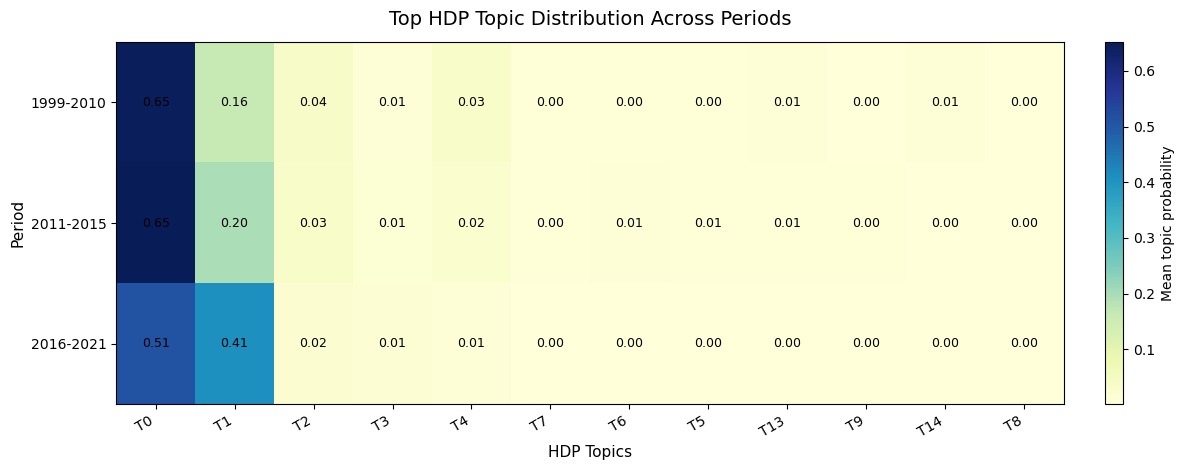

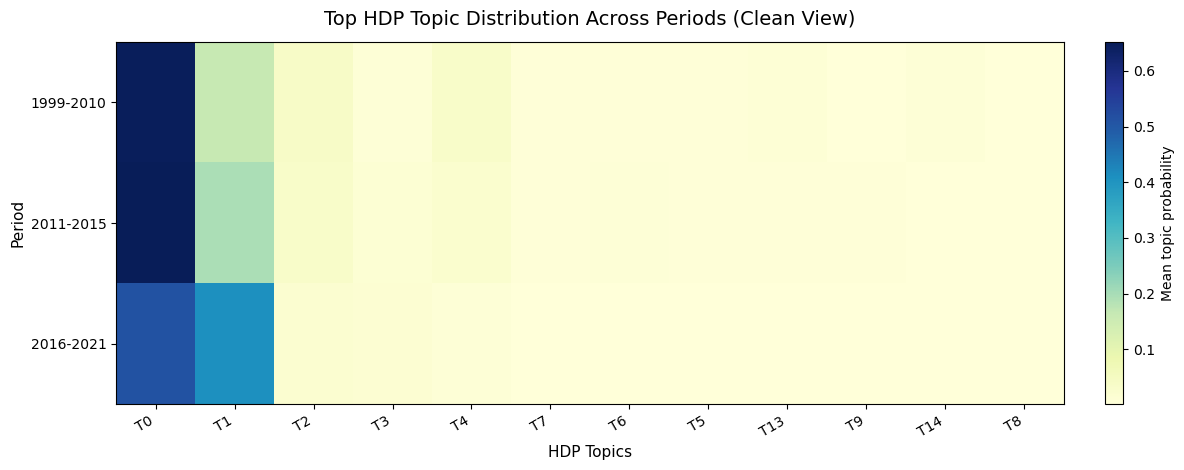


=== HDP Period Distance Matrix ===
              1999-2010     2011-2015     2016-2021
1999-2010 -2.220446e-16  1.247147e-03  9.076577e-02
2011-2015  1.247147e-03  3.330669e-16  7.273277e-02
2016-2021  9.076577e-02  7.273277e-02  2.220446e-16


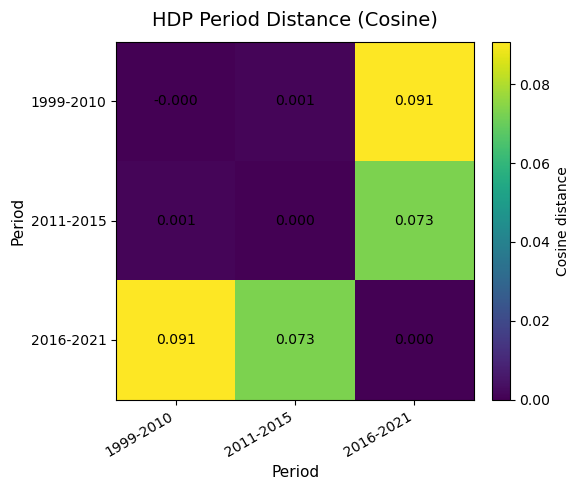

In [ ]:

# HDP model
# This section applies HDP (Hierarchical Dirichlet Process) for topic modeling on the entire corpus.
# Unlike LDA, HDP does not require specifying the number of topics in advance, as it automatically
# learns an appropriate topic structure from the data.
# The code first builds a dictionary and corpus, then trains a global HDP model. After that, it extracts
# document-topic distributions and converts the sparse representations into dense vectors.
# To simplify analysis and visualization, only the globally most important topics (based on average weights)
# are retained. These topic vectors are then aggregated by period to obtain a topic profile for each time period.
# Finally, the code outputs top topics per period, visualizes them using heatmaps, and computes cosine distances
# between periods to compare how topic distributions evolve over time.
from gensim.corpora import Dictionary
from gensim.models import HdpModel
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _df_heatmap(
    df,
    title,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    figsize=(12, 4.8),
    cbar_label="",
    square=False,
    xlabel="",
    ylabel="",
):
    """Matplotlib heatmap (no seaborn required)."""
    arr = df.values.astype(float)
    h, w = arr.shape
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(arr, cmap=cmap, aspect="equal" if square else "auto")
    ax.set_xticks(np.arange(w))
    ax.set_yticks(np.arange(h))
    ax.set_xticklabels(df.columns, rotation=30, ha="right")
    ax.set_yticklabels(df.index)
    if annot:
        for i in range(h):
            for j in range(w):
                ax.text(
                    j,
                    i,
                    format(arr[i, j], fmt),
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=9 if not square else 10,
                )
    ax.set_title(title, fontsize=14, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=11)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=cbar_label)
    plt.tight_layout()
    plt.show()


#  Prepare corpus

texts_hdp = df["tokens"].tolist()

dictionary = Dictionary(texts_hdp)
dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = [dictionary.doc2bow(text) for text in texts_hdp]

print("Number of documents:", len(corpus))
print("Vocabulary size:", len(dictionary))


# Train HDP

hdp_model = HdpModel(corpus=corpus, id2word=dictionary)

print("\n=== Sample HDP Topics ===")
for idx, topic in hdp_model.print_topics(num_topics=10, num_words=10):
    print(f"\n===== Topic {idx} =====")
    print(topic)
 
# Get document-topic distributions
doc_topics_hdp = [hdp_model[doc] for doc in corpus]

all_topic_ids = sorted({
    tid for doc in doc_topics_hdp for tid, _ in doc
})

print("\nNumber of used HDP topics:", len(all_topic_ids))
print("First 30 topic ids:", all_topic_ids[:30])

topic_id_to_idx = {tid: i for i, tid in enumerate(all_topic_ids)}
idx_to_topic_id = {i: tid for tid, i in topic_id_to_idx.items()}

def dense_topic_vector_hdp(topic_dist, topic_id_to_idx):
    vec = np.zeros(len(topic_id_to_idx))
    for topic_id, prob in topic_dist:
        vec[topic_id_to_idx[topic_id]] = prob
    return vec

hdp_dense = np.array([
    dense_topic_vector_hdp(topic_dist, topic_id_to_idx)
    for topic_dist in doc_topics_hdp
])

print("Dense HDP matrix shape:", hdp_dense.shape)


# Keep only globally important topics

top_n = min(12, hdp_dense.shape[1])   # 20 was crowded; 12 fits the figure better

topic_means = hdp_dense.mean(axis=0)
top_idx = np.argsort(topic_means)[-top_n:]
top_idx = top_idx[np.argsort(topic_means[top_idx])[::-1]]

hdp_dense_top = hdp_dense[:, top_idx]
top_topic_ids = [idx_to_topic_id[i] for i in top_idx]

print("\nTop selected HDP topic ids:", top_topic_ids)

df["hdp_topic_vector"] = list(hdp_dense_top)


# Aggregate by period

period_hdp = {}

for period, group in df.groupby("period"):
    vecs = np.vstack(group["hdp_topic_vector"].values)
    period_hdp[period] = vecs.mean(axis=0)

period_hdp_df = pd.DataFrame(period_hdp).T

# Shorter column names for clearer plots
short_topic_labels = [f"T{tid}" for tid in top_topic_ids]
period_hdp_df.columns = short_topic_labels

print("\n=== Period-topic matrix ===")
print(period_hdp_df.head())


# Show top topics per period

print("\n=== Top HDP Topics Per Period ===")
for period in period_hdp_df.index:
    print(f"\n========== {period} ==========")
    top_topics = period_hdp_df.loc[period].sort_values(ascending=False).head(3)

    for col_name, score in top_topics.items():
        topic_id = int(col_name.replace("T", ""))
        print(f"\n{col_name} | weight = {score:.4f}")
        print(hdp_model.print_topic(topic_id, topn=10))


# Heatmap of top HDP topics across periods (matplotlib only)

_df_heatmap(
    period_hdp_df,
    title="Top HDP Topic Distribution Across Periods",
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    figsize=(12, 4.8),
    cbar_label="Mean topic probability",
    xlabel="HDP Topics",
    ylabel="Period",
)

_df_heatmap(
    period_hdp_df,
    title="Top HDP Topic Distribution Across Periods (Clean View)",
    cmap="YlGnBu",
    annot=False,
    fmt=".2f",
    figsize=(12, 4.8),
    cbar_label="Mean topic probability",
    xlabel="HDP Topics",
    ylabel="Period",
)

# =======================
# 9. Cosine distance between periods
# =======================
sim_matrix = cosine_similarity(period_hdp_df.values)
dist_matrix = 1 - sim_matrix

dist_hdp_df = pd.DataFrame(
    dist_matrix,
    index=period_hdp_df.index,
    columns=period_hdp_df.index
)

print("\n=== HDP Period Distance Matrix ===")
print(dist_hdp_df)

_df_heatmap(
    dist_hdp_df,
    title="HDP Period Distance (Cosine)",
    cmap="viridis",
    annot=True,
    fmt=".3f",
    figsize=(6, 5),
    cbar_label="Cosine distance",
    square=True,
    xlabel="Period",
    ylabel="Period",
)

# The results show that although HDP automatically learns many topics (148 topics are used),
# the high-weight topics are not well separated. The sample topics and top topics per period
# repeatedly contain very similar keywords such as network, training, neural, graph, and feature,
# suggesting considerable overlap between topics and weaker semantic boundaries than BERTopic
# or some of the LDA results. In the period-topic matrix, T0 remains dominant across all periods
# and increases further in 2016–2021; T1 becomes much stronger in the later period, while T3 decreases.
# This indicates that HDP still captures temporal change, but mainly as a redistribution of weights
# among similar topics rather than clearly differentiated semantic shifts. The cosine distance matrix
# also shows that 1999–2010 and 2011–2015 are most similar (0.015), while 2016–2021 differs more,
# especially from 1999–2010 (0.121), confirming that later topic structure changes. Overall,
# HDP has the advantage of not requiring a predefined number of topics and is useful for capturing
# broad temporal trends, but its topics are more fragmented and overlapping, making interpretation weaker
# than BERTopic and less clear than the better LDA settings. Therefore, HDP is more suitable as a
# supplementary comparison method rather than the main explanatory model.


In [ ]:
# --- Extra hyperparameter sweeps: TF–IDF (fast) + optional BERTopic min_topic_size ---
# Run order: after TF–IDF cell (`all_stopwords`, `df`) and after `run_bertopic_experiment` exists (BERTopic section).

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# ----- 1) TF–IDF (unigram) small grid -----
RUN_TFIDF_SWEEP = True  # set False to skip

texts_tfidf = df["clean_text_tfidf_lda"].astype(str).tolist()

tfidf_configs = [
    {"name": "default", "max_features": 5000, "max_df": 0.5, "min_df": 5},
    {"name": "more_vocab", "max_features": 8000, "max_df": 0.5, "min_df": 3},
    {"name": "stricter_df", "max_features": 5000, "max_df": 0.35, "min_df": 8},
]

watch_terms = ["neural", "deep", "graph", "training", "network"]

tfidf_sweep_rows = []
if RUN_TFIDF_SWEEP:
    for cfg in tfidf_configs:
        vec = TfidfVectorizer(
            max_features=cfg["max_features"],
            stop_words=all_stopwords,
            max_df=cfg["max_df"],
            min_df=cfg["min_df"],
        )
        X = vec.fit_transform(texts_tfidf)
        n_docs, n_terms = X.shape
        nnz = X.nnz
        density = nnz / float(n_docs * n_terms) if n_docs * n_terms else 0.0
        feats = vec.get_feature_names_out()
        idx_map = {t: i for i, t in enumerate(feats)}
        rec = {
            "config_name": cfg["name"],
            "max_features": cfg["max_features"],
            "max_df": cfg["max_df"],
            "min_df": cfg["min_df"],
            "vocabulary_size": int(n_terms),
            "matrix_nnz": int(nnz),
            "density": round(density, 6),
        }
        for period in sorted(df["period"].unique()):
            mask = (df["period"] == period).to_numpy()
            sub_mean = np.asarray(X[mask].mean(axis=0)).ravel()
            for w in watch_terms:
                j = idx_map.get(w)
                key = f"mean_{w}_{period.replace('-', '_')}"
                rec[key] = float(sub_mean[j]) if j is not None else float("nan")
        tfidf_sweep_rows.append(rec)

    tfidf_sweep_df = pd.DataFrame(tfidf_sweep_rows)
    print("\n=== TF–IDF parameter sweep (unigram) ===\n")
    display(tfidf_sweep_df)

# ----- 2) BERTopic: min_topic_size only (baseline MiniLM + HDBSCAN) — slow -----
RUN_BERTOPIC_MTS_SWEEP = False  # set True for 3 extra full fits (~3× baseline embedding time)

if RUN_BERTOPIC_MTS_SWEEP:
    bertopic_texts = df["clean_text_embed"].astype(str).tolist()
    mts_grid = [35, 50, 65]
    bert_mts_rows = []
    for mts in mts_grid:
        tm, top, _pr = run_bertopic_experiment(
            bertopic_texts,
            embedding_name="all-MiniLM-L6-v2",
            use_kmeans=False,
            reduce_outliers_flag=False,
            min_topic_size=mts,
        )
        s = pd.Series(top)
        n_topics = int(s[s != -1].nunique())
        outlier_r = float((s == -1).mean())
        bert_mts_rows.append(
            {
                "min_topic_size": mts,
                "n_topics_excl_noise": n_topics,
                "outlier_ratio": outlier_r,
            }
        )
    bert_mts_df = pd.DataFrame(bert_mts_rows)
    print("\n=== BERTopic min_topic_size sweep (baseline only) ===\n")
    display(bert_mts_df)

print(
    "\nCopy `tfidf_sweep_df` (and `bert_mts_df` if run) into the report §4.1 / §6, or paste notebook output to the assistant."
)


=== TF–IDF parameter sweep (unigram) ===



,config_name,max_features,max_df,min_df,vocabulary_size,matrix_nnz,density,mean_neural_1999_2010,mean_deep_1999_2010,mean_graph_1999_2010,...,mean_neural_2011_2015,mean_deep_2011_2015,mean_graph_2011_2015,mean_training_2011_2015,mean_network_2011_2015,mean_neural_2016_2021,mean_deep_2016_2021,mean_graph_2016_2021,mean_training_2016_2021,mean_network_2016_2021
0,default,5000,0.50,5,5000,426815,0.012169,0.002875,0.0,0.005211,...,0.006692,0.009694,0.010533,0.014649,0.013231,0.023833,0.020356,0.026262,0.023567,0.034072
1,more_vocab,8000,0.50,3,7778,438589,0.008038,0.002643,0.0,0.005152,...,0.006495,0.009339,0.010332,0.014181,0.012797,0.023063,0.019651,0.025596,0.022819,0.032997
2,stricter_df,5000,0.35,8,4642,416960,0.012804,0.002915,0.0,0.005226,...,0.006796,0.009838,0.010773,0.014857,NaN,0.024434,0.020768,0.026649,0.023994,NaN



Copy `tfidf_sweep_df` (and `bert_mts_df` if run) into the report §4.1 / §6, or paste notebook output to the assistant.


In [ ]:
# HDP separately for each period
# This section trains a separate HDP model for each time period instead of using a global model.
# The dataset is first grouped by period, and for each subset, a dictionary and corpus are built,
# followed by training an HDP model. For each period, document-topic distributions are extracted,
# and the average weight of each topic is computed to identify the most important topics in that period.
# The models, corpora, and topic distributions are stored for further analysis and comparison.
# Finally, the top topics from each period are summarized into a table to compare topic structures across time.

from gensim.corpora import Dictionary
from gensim.models import HdpModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0. Check periods

print(df["period"].value_counts())


# 1. Containers

period_hdp_models = {}
period_hdp_dictionaries = {}
period_hdp_corpora = {}
period_hdp_doc_topics = {}
period_hdp_topic_summary = {}


# 2. Train one HDP per period

for period, group in df.groupby("period"):
    print(f"\n==============================")
    print(f"Training HDP for period: {period}")
    print(f"Number of documents: {len(group)}")
    print(f"==============================")
    
    texts_period = group["tokens"].tolist()
    
    # Build dictionary
    dictionary = Dictionary(texts_period)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    
    # Build corpus
    corpus = [dictionary.doc2bow(text) for text in texts_period]
    
    print("Vocabulary size:", len(dictionary))
    
    # Train HDP
    hdp_model = HdpModel(corpus=corpus, id2word=dictionary)
    # alpha=0.01, gamma=0.01: optional ablation settings
    
    
    # Save objects
    period_hdp_models[period] = hdp_model
    period_hdp_dictionaries[period] = dictionary
    period_hdp_corpora[period] = corpus
    
    # Document-topic distributions
    doc_topics = [hdp_model[doc] for doc in corpus]
    period_hdp_doc_topics[period] = doc_topics
    
    # Print sample topics
    print(f"\n=== Sample topics for {period} ===")
    for idx, topic in hdp_model.print_topics(num_topics=10, num_words=10):
        print(f"\n----- Topic {idx} -----")
        print(topic)


# 3. Show top topics per period

print("\n\n==============================")
print("Top HDP topics in each period")
print("==============================")

for period, hdp_model in period_hdp_models.items():
    doc_topics = period_hdp_doc_topics[period]
    
    # collect all topic ids used in this period
    all_topic_ids = sorted({
        tid for doc in doc_topics for tid, _ in doc
    })
    
    # average topic weights over all documents in this period
    topic_avg = {}
    for tid in all_topic_ids:
        vals = []
        for doc in doc_topics:
            score = 0.0
            for topic_id, prob in doc:
                if topic_id == tid:
                    score = prob
                    break
            vals.append(score)
        topic_avg[tid] = np.mean(vals)
    
    # sort top topics
    top_topics = sorted(topic_avg.items(), key=lambda x: x[1], reverse=True)[:5]
    period_hdp_topic_summary[period] = top_topics
    
    print(f"\n========== {period} ==========")
    for tid, score in top_topics:
        print(f"\nTopic {tid} | mean weight = {score:.4f}")
        print(hdp_model.print_topic(tid, topn=10))


# 4.summary table
summary_rows = []

for period, top_topics in period_hdp_topic_summary.items():
    for rank, (tid, score) in enumerate(top_topics, start=1):
        words = period_hdp_models[period].print_topic(tid, topn=10)
        summary_rows.append({
            "period": period,
            "rank": rank,
            "topic_id": tid,
            "mean_weight": score,
            "topic_words": words
        })

summary_df = pd.DataFrame(summary_rows)

print("\n=== Summary table ===")
print(summary_df)
# This summary table lists the top 5 topics per period by mean_weight (average mass on that
# HDP topic id within the period). HDP ids are not aligned across periods—read keywords from
# print_topic next to the numeric weights you actually obtained.
#
# Typical pattern to check in your printed output (confirm numbers in summary_df):
# (1) Early slice: weights relatively flat—many small topics, weaker concentration.
# (2) Middle slice: one or a few topics may spike if the model finds a broad dominant theme.
# (3) Late slice: mass often collapses onto very few topics whose words overlap (neural/graph/training),
#     which can look like one big deep-learning bucket even when human themes would be finer.
#
# Use the table as evidence of dispersion vs concentration; treat overlapping late HDP topics
# as a model limitation, not as perfectly separated research areas.


period
2016-2021    5743
2011-2015    1028
1999-2010     244
Name: count, dtype: int64

Training HDP for period: 1999-2010
Number of documents: 244
Vocabulary size: 670

=== Sample topics for 1999-2010 ===

----- Topic 0 -----
0.009*asymptotically + 0.008*noise + 0.008*solving + 0.007*form + 0.007*linear + 0.007*interpretation + 0.007*conjugate + 0.006*describes + 0.006*estimation + 0.006*stochastic

----- Topic 1 -----
0.008*dataset + 0.008*active + 0.007*markov + 0.007*dual + 0.006*exactly + 0.006*obtained + 0.006*feedback + 0.006*advance + 0.006*predictor + 0.006*additional

----- Topic 2 -----
0.014*uncertainty + 0.009*logistic + 0.009*expression + 0.008*satisfying + 0.008*information + 0.007*sampling + 0.007*efficiency + 0.007*dimensional + 0.007*increasing + 0.007*robustness

----- Topic 3 -----
0.010*difficult + 0.009*pattern + 0.008*observed + 0.008*markov + 0.008*distinct + 0.008*generate + 0.007*describes + 0.007*like + 0.007*generalization + 0.007*clustering

----- Topic 4 -

In [ ]:
# Training HDP separately per period highlights how corpus size and vocabulary affect estimates:
# early slices are sparse, so topic weights are often small and noisy; later slices are larger and
# may concentrate mass on a few HDP topics whose keywords overlap (network, training, neural, graph, deep, …).
# Check the numeric mean_weight values you printed—do not assume fixed numbers like 0.654/0.245 across reruns.
#
# Overall, period-specific HDP can illustrate dispersion → concentration, but overlapping late topics mean
# it is best as a supplementary view next to LDA/BERTopic with clearer separation.

In [ ]:
import pandas as pd

temporal_compare = pd.DataFrame({
    "Pair": [
        "1999-2010 vs 2011-2015",
        "1999-2010 vs 2016-2021",
        "2011-2015 vs 2016-2021",
    ],
    "Global_LDA_cosine_distance": [0.037, 0.256, 0.136],
    "HDP_cosine_distance": [0.000871, 0.0400, 0.0345],
})

display(temporal_compare)

# Optional rank check: larger distance = more different periods
temporal_compare["LDA_rank"] = temporal_compare["Global_LDA_cosine_distance"].rank(
    ascending=False, method="min"
)
temporal_compare["HDP_rank"] = temporal_compare["HDP_cosine_distance"].rank(
    ascending=False, method="min"
)
display(temporal_compare)


,Pair,Global_LDA_cosine_distance,HDP_cosine_distance
0,1999-2010 vs 2011-2015,0.037,0.000871
1,1999-2010 vs 2016-2021,0.256,0.040000
2,2011-2015 vs 2016-2021,0.136,0.034500


,Pair,Global_LDA_cosine_distance,HDP_cosine_distance,LDA_rank,HDP_rank
0,1999-2010 vs 2011-2015,0.037,0.000871,3.0,3.0
1,1999-2010 vs 2016-2021,0.256,0.040000,1.0,1.0
2,2011-2015 vs 2016-2021,0.136,0.034500,2.0,2.0


In [ ]:
# Patch: safer BERTopic runner for min_topic_size sweeps
# Run this cell once, then rerun your sweep cell.

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from umap import UMAP

_embedding_cache = globals().get("_embedding_cache", {})


def _get_embedding_model(name):
    if name not in _embedding_cache:
        _embedding_cache[name] = SentenceTransformer(name)
    return _embedding_cache[name]


def run_bertopic_experiment(
    texts,
    embedding_name="all-MiniLM-L6-v2",
    use_kmeans=False,
    reduce_outliers_flag=False,
    min_topic_size=50,
    n_clusters=20,
    vectorizer_min_df=1,
    vectorizer_max_df=1.0,
):
    print("\n===== Running BERTopic =====")
    print(f"Embedding: {embedding_name}")
    print(f"KMeans: {use_kmeans}")
    print(f"Reduce outliers: {reduce_outliers_flag}")

    # Ensure BERTopic receives plain strings
    docs = ["" if x is None else str(x) for x in texts]

    embedding_model = _get_embedding_model(embedding_name)

    # min_df=1 avoids failures when topic-level c-TF-IDF sees few grouped docs
    vectorizer_model = CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=vectorizer_min_df,
        max_df=vectorizer_max_df,
    )

    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric="cosine",
        random_state=42,
        n_jobs=1,
        low_memory=True,
    )

    cluster_model = KMeans(n_clusters=n_clusters, random_state=42) if use_kmeans else None

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        calculate_probabilities=False,
        verbose=True,
        min_topic_size=min_topic_size,
    )

    topics, probs = topic_model.fit_transform(docs)

    if reduce_outliers_flag:
        print("Reducing outliers...")
        topics = topic_model.reduce_outliers(docs, topics, strategy="c-tf-idf")

    return topic_model, topics, probs


print("Patched run_bertopic_experiment loaded. Now rerun your BERTopic sweep cell.")


Patched run_bertopic_experiment loaded. Now rerun your BERTopic sweep cell.
